# Lección 3 - Sistemas de Ecuaciones Diferenciales Lineales

**Ampliación de Matemáticas - GIERM**

---

## Objetivos de aprendizaje

- Reducir una EDO de orden superior a un sistema de primer orden
- Resolver sistemas homogéneos $\mathbf{y}'=A\mathbf{y}$ mediante autovalores y autovectores
- Clasificar retratos de fase: nodo, silla, espiral, centro
- Tratar el caso no diagonalizable con cadenas de Jordan
- Resolver sistemas no homogéneos por variación de parámetros, coeficientes indeterminados y Laplace
- Verificar soluciones numéricamente con `scipy.integrate.solve_ivp`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from scipy.linalg import expm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul
COLOR_RECTA = '#cb181d'       # rojo
COLOR_PUNTO = '#238b45'       # verde
COLOR_AUX = '#ff7f00'         # naranja
COLOR_AUX2 = '#6a3d9a'        # púrpura

print('Configuración lista.')

Configuración lista.


---

## 1. Reducción de orden: de EDO de orden $n$ a sistema de primer orden

Toda EDO de orden $n$ se puede reescribir como un **sistema de $n$ ecuaciones de primer orden**. Esto unifica el tratamiento de todas las EDO lineales.

### 1.1 Método general

Dada la EDO de orden 2:

$$x'' = f(x', x, t)$$

Definimos las variables de estado $y_1 = x$, $y_2 = x'$. Entonces:

$$\boxed{\begin{cases} y_1' = y_2 \\ y_2' = f(y_2, y_1, t) \end{cases}}$$

### Ejemplo

La EDO $x'' + 3x' + 2x = \cos(t)$ se convierte en:

$$\begin{cases} y_1' = y_2 \\ y_2' = -2y_1 - 3y_2 + \cos(t) \end{cases}$$

En forma matricial:

$$\mathbf{y}' = \begin{pmatrix} 0 & 1 \\ -2 & -3 \end{pmatrix} \mathbf{y} + \begin{pmatrix} 0 \\ \cos(t) \end{pmatrix}$$

### Generalización a orden $n$

Para $x^{(n)} + a_{n-1}x^{(n-1)} + \cdots + a_1 x' + a_0 x = g(t)$, definimos $y_k = x^{(k-1)}$:

$$A = \begin{pmatrix} 0 & 1 & 0 & \cdots & 0 \\ 0 & 0 & 1 & \cdots & 0 \\ \vdots & & & \ddots & \vdots \\ 0 & 0 & 0 & \cdots & 1 \\ -a_0 & -a_1 & -a_2 & \cdots & -a_{n-1} \end{pmatrix}$$

Esta es la **matriz compañera** de la EDO.

---

## 2. Sistema lineal $\mathbf{y}' = A\mathbf{y} + \mathbf{f}(t)$

### 2.1 Teorema de existencia y unicidad

Si $A$ es una matriz $n \times n$ de coeficientes constantes y $\mathbf{f}(t)$ es continua en un intervalo $I$, entonces para cada condición inicial $\mathbf{y}(t_0) = \mathbf{y}_0$ existe una **única** solución definida en todo $I$.

### 2.2 Estructura de la solución general

$$\boxed{\mathbf{y}(t) = \mathbf{y}_p(t) + Y(t)\mathbf{c}}$$

donde:
- $\mathbf{y}_p(t)$ es una **solución particular** del sistema completo
- $Y(t)$ es la **matriz fundamental** (columnas = $n$ soluciones linealmente independientes del homogéneo)
- $\mathbf{c} \in \mathbb{R}^n$ es el vector de constantes arbitrarias

### 2.3 Matriz fundamental y Wronskiano

La matriz fundamental $Y(t)$ satisface $Y'(t) = AY(t)$, y su determinante $W(t) = \det(Y(t)) \neq 0$ para todo $t$ (Wronskiano).

**Propiedad clave:** $W(t) = W(t_0) \cdot e^{\text{tr}(A)(t-t_0)}$ (fórmula de Abel-Liouville).

---

## 3. Sistema homogéneo $\mathbf{y}' = A\mathbf{y}$ con $A$ diagonalizable

### 3.1 Autovalores reales distintos

Si $A$ tiene autovalores $\lambda_1, \lambda_2, \ldots, \lambda_n$ todos distintos con autovectores $\mathbf{u}_1, \mathbf{u}_2, \ldots, \mathbf{u}_n$, la solución general es:

$$\boxed{\mathbf{y}(t) = c_1 e^{\lambda_1 t} \mathbf{u}_1 + c_2 e^{\lambda_2 t} \mathbf{u}_2 + \cdots + c_n e^{\lambda_n t} \mathbf{u}_n}$$

**¿Por qué funciona?** Si $A\mathbf{u} = \lambda \mathbf{u}$, entonces $\mathbf{y}(t) = e^{\lambda t}\mathbf{u}$ satisface $\mathbf{y}' = \lambda e^{\lambda t}\mathbf{u} = A(e^{\lambda t}\mathbf{u}) = A\mathbf{y}$.

### 3.2 Autovalores complejos conjugados

Si $\lambda = \alpha \pm i\beta$ con autovector $\mathbf{u} = \mathbf{v} + i\mathbf{w}$, las dos soluciones reales linealmente independientes son:

$$\boxed{\begin{aligned} \mathbf{y}_1(t) &= e^{\alpha t}[\mathbf{v}\cos(\beta t) - \mathbf{w}\sin(\beta t)] \\ \mathbf{y}_2(t) &= e^{\alpha t}[\mathbf{v}\sin(\beta t) + \mathbf{w}\cos(\beta t)] \end{aligned}}$$

- Si $\alpha < 0$: **espiral estable** (atractora)
- Si $\alpha > 0$: **espiral inestable** (repulsora)
- Si $\alpha = 0$: **centro** (órbitas cerradas)

### 3.3 Ejemplo: sistema 3×3 diagonalizable

Resolver $\mathbf{y}' = A\mathbf{y}$ con:

$$A = \begin{pmatrix} 1 & 0 & 0 \\ 0 & -1 & 2 \\ 0 & -2 & -1 \end{pmatrix}$$

**Paso 1:** Polinomio característico:

$$\det(A - \lambda I) = (1 - \lambda)[(−1−\lambda)^2 + 4] = 0$$

**Paso 2:** Autovalores:

$$\lambda_1 = 1, \qquad \lambda_{2,3} = -1 \pm 2i$$

**Paso 3:** Autovector para $\lambda_1 = 1$:

$$(A - I)\mathbf{u}_1 = \mathbf{0} \implies \mathbf{u}_1 = \begin{pmatrix} 1 \\ 0 \\ 0 \end{pmatrix}$$

**Paso 4:** Para $\lambda = -1 + 2i$, resolvemos $(A - \lambda I)\mathbf{u} = \mathbf{0}$:

$$\mathbf{u} = \begin{pmatrix} 0 \\ 1 \\ i \end{pmatrix} = \underbrace{\begin{pmatrix} 0 \\ 1 \\ 0 \end{pmatrix}}_{\mathbf{v}} + i\underbrace{\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}}_{\mathbf{w}}$$

**Paso 5:** Solución general ($\alpha = -1$, $\beta = 2$):

$$\boxed{\mathbf{y}(t) = c_1 e^{t}\begin{pmatrix}1\\0\\0\end{pmatrix} + c_2 e^{-t}\begin{pmatrix}0\\\cos 2t\\-\sin 2t\end{pmatrix} + c_3 e^{-t}\begin{pmatrix}0\\\sin 2t\\\cos 2t\end{pmatrix}}$$

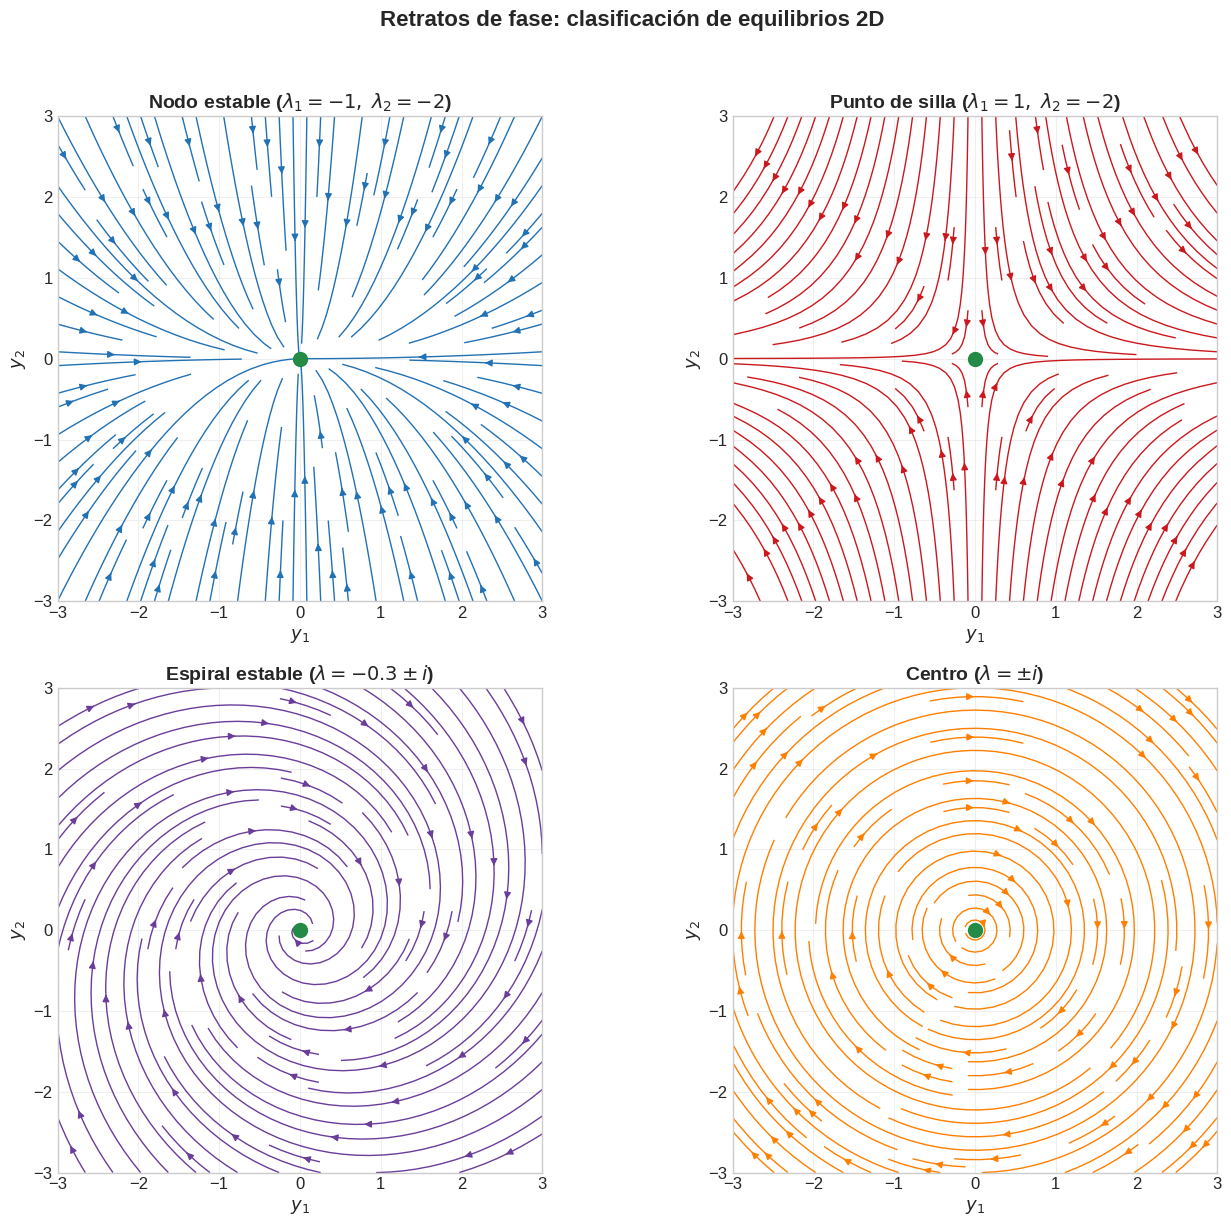

In [2]:
# Retratos de fase: 4 tipos de equilibrio en sistemas 2D
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Nodo estable: lambda1=-1, lambda2=-2 ---
ax = axes[0, 0]
A_node = np.array([[-1, 0], [0, -2]])
Y, X = np.mgrid[-3:3:20j, -3:3:20j]
U = A_node[0, 0] * X + A_node[0, 1] * Y
V = A_node[1, 0] * X + A_node[1, 1] * Y
ax.streamplot(X, Y, U, V, color=COLOR_PRINCIPAL, density=1.2, linewidth=1)
ax.set_title(r'Nodo estable ($\lambda_1=-1,\;\lambda_2=-2$)', fontweight='bold')
ax.set_xlabel(r'$y_1$')
ax.set_ylabel(r'$y_2$')
ax.plot(0, 0, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Punto de silla: lambda1=1, lambda2=-2 ---
ax = axes[0, 1]
A_saddle = np.array([[1, 0], [0, -2]])
U = A_saddle[0, 0] * X + A_saddle[0, 1] * Y
V = A_saddle[1, 0] * X + A_saddle[1, 1] * Y
ax.streamplot(X, Y, U, V, color=COLOR_RECTA, density=1.2, linewidth=1)
ax.set_title(r'Punto de silla ($\lambda_1=1,\;\lambda_2=-2$)', fontweight='bold')
ax.set_xlabel(r'$y_1$')
ax.set_ylabel(r'$y_2$')
ax.plot(0, 0, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Espiral estable: alpha=-0.3, beta=1 ---
ax = axes[1, 0]
A_spiral = np.array([[-0.3, 1], [-1, -0.3]])
U = A_spiral[0, 0] * X + A_spiral[0, 1] * Y
V = A_spiral[1, 0] * X + A_spiral[1, 1] * Y
ax.streamplot(X, Y, U, V, color=COLOR_AUX2, density=1.2, linewidth=1)
ax.set_title(r'Espiral estable ($\lambda=-0.3 \pm i$)', fontweight='bold')
ax.set_xlabel(r'$y_1$')
ax.set_ylabel(r'$y_2$')
ax.plot(0, 0, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Centro: alpha=0, beta=1 ---
ax = axes[1, 1]
A_center = np.array([[0, 1], [-1, 0]])
U = A_center[0, 0] * X + A_center[0, 1] * Y
V = A_center[1, 0] * X + A_center[1, 1] * Y
ax.streamplot(X, Y, U, V, color=COLOR_AUX, density=1.2, linewidth=1)
ax.set_title(r'Centro ($\lambda=\pm i$)', fontweight='bold')
ax.set_xlabel(r'$y_1$')
ax.set_ylabel(r'$y_2$')
ax.plot(0, 0, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

fig.suptitle('Retratos de fase: clasificación de equilibrios 2D', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Clasificación de puntos de equilibrio en $\mathbb{R}^2$

| Autovalores | Tipo | Estabilidad |
|-------------|------|-------------|
| $\lambda_1 < \lambda_2 < 0$ | **Nodo estable** | Asintóticamente estable |
| $0 < \lambda_1 < \lambda_2$ | **Nodo inestable** | Inestable |
| $\lambda_1 < 0 < \lambda_2$ | **Punto de silla** | Inestable |
| $\alpha \pm i\beta$, $\alpha < 0$ | **Espiral estable** | Asintóticamente estable |
| $\alpha \pm i\beta$, $\alpha > 0$ | **Espiral inestable** | Inestable |
| $\pm i\beta$ (puros imaginarios) | **Centro** | Estable (no asint.) |
| $\lambda_1 = \lambda_2 < 0$, diag. | **Nodo estrella estable** | Asintóticamente estable |
| $\lambda_1 = \lambda_2 < 0$, no diag. | **Nodo impropio estable** | Asintóticamente estable |

**Truco para el examen:** La traza $\text{tr}(A) = \lambda_1 + \lambda_2$ y el determinante $\det(A) = \lambda_1 \lambda_2$ determinan completamente el tipo:
- $\det(A) < 0 \implies$ silla
- $\det(A) > 0$ y $\text{tr}(A) < 0 \implies$ estable
- $\text{tr}(A)^2 - 4\det(A) < 0 \implies$ espiral/centro

---

## 4. Sistema homogéneo con $A$ no diagonalizable

### 4.1 Autovectores generalizados y cadenas de Jordan

Cuando $A$ tiene un autovalor $\lambda$ de multiplicidad algebraica $m$ pero multiplicidad geométrica $p < m$, no hay suficientes autovectores. Se necesitan **autovectores generalizados**.

**Cadena de Jordan** de longitud $k$ para $\lambda$:

$$(A - \lambda I)\mathbf{u}_k = \mathbf{0}, \quad (A - \lambda I)\mathbf{u}_{k-1} = \mathbf{u}_k, \quad \ldots, \quad (A - \lambda I)\mathbf{u}_1 = \mathbf{u}_2$$

### 4.2 Soluciones asociadas a un bloque de Jordan 2×2

Para un bloque de Jordan $\begin{pmatrix} \lambda & 1 \\ 0 & \lambda \end{pmatrix}$ con autovector $\mathbf{u}$ y autovector generalizado $\mathbf{w}$ ($(A-\lambda I)\mathbf{w} = \mathbf{u}$):

$$\boxed{\begin{aligned} \mathbf{y}_1(t) &= e^{\lambda t} \mathbf{u} \\ \mathbf{y}_2(t) &= e^{\lambda t}(t\mathbf{u} + \mathbf{w}) \end{aligned}}$$

### 4.3 Fórmula general con exponencial matricial

$$\mathbf{y}(t) = e^{At}\mathbf{y}_0$$

donde para un bloque de Jordan $J_k(\lambda)$ de tamaño $k$:

$$e^{J_k(\lambda)t} = e^{\lambda t} \begin{pmatrix} 1 & t & \frac{t^2}{2!} & \cdots \\ 0 & 1 & t & \cdots \\ \vdots & & \ddots & \vdots \\ 0 & 0 & \cdots & 1 \end{pmatrix}$$

### 4.4 Ejemplo 2×2 no diagonalizable

Resolver $\mathbf{y}' = A\mathbf{y}$ con $A = \begin{pmatrix} 3 & 1 \\ 0 & 3 \end{pmatrix}$, $\mathbf{y}(0) = \begin{pmatrix} 1 \\ 2 \end{pmatrix}$.

**Paso 1:** $\det(A - \lambda I) = (3-\lambda)^2 = 0 \implies \lambda = 3$ (doble).

**Paso 2:** Autovector: $(A - 3I)\mathbf{u} = \mathbf{0}$

$$(A-3I) = \begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix} \implies \mathbf{u} = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

Solo un autovector $\implies$ $A$ **no es diagonalizable**.

**Paso 3:** Autovector generalizado: $(A - 3I)\mathbf{w} = \mathbf{u}$

$$\begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix}\mathbf{w} = \begin{pmatrix} 1 \\ 0 \end{pmatrix} \implies w_2 = 1 \implies \mathbf{w} = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

**Paso 4:** Solución general:

$$\mathbf{y}(t) = c_1 e^{3t}\begin{pmatrix}1\\0\end{pmatrix} + c_2 e^{3t}\left[t\begin{pmatrix}1\\0\end{pmatrix} + \begin{pmatrix}0\\1\end{pmatrix}\right]$$

**Paso 5:** Condición inicial $\mathbf{y}(0) = \begin{pmatrix}1\\2\end{pmatrix}$:

$$c_1 = 1, \quad c_2 = 2$$

$$\boxed{\mathbf{y}(t) = e^{3t}\begin{pmatrix}1 + 2t\\2\end{pmatrix}}$$

### 4.5 Ejemplo 3×3 no diagonalizable

Resolver $\mathbf{y}' = A\mathbf{y}$ con:

$$A = \begin{pmatrix} 2 & 1 & 0 \\ 0 & 2 & 1 \\ 0 & 0 & 2 \end{pmatrix}$$

$\lambda = 2$ con multiplicidad algebraica 3, multiplicidad geométrica 1.

**Cadena de Jordan:** $\mathbf{u}_3 = \begin{pmatrix}1\\0\\0\end{pmatrix}$, $(A-2I)\mathbf{u}_2 = \mathbf{u}_3 \implies \mathbf{u}_2 = \begin{pmatrix}0\\1\\0\end{pmatrix}$, $(A-2I)\mathbf{u}_1 = \mathbf{u}_2 \implies \mathbf{u}_1 = \begin{pmatrix}0\\0\\1\end{pmatrix}$.

**Solución general:**

$$\boxed{\mathbf{y}(t) = e^{2t}\left[c_1\begin{pmatrix}1\\0\\0\end{pmatrix} + c_2\left(t\begin{pmatrix}1\\0\\0\end{pmatrix}+\begin{pmatrix}0\\1\\0\end{pmatrix}\right) + c_3\left(\frac{t^2}{2}\begin{pmatrix}1\\0\\0\end{pmatrix}+t\begin{pmatrix}0\\1\\0\end{pmatrix}+\begin{pmatrix}0\\0\\1\end{pmatrix}\right)\right]}$$

Equivalentemente:

$$\mathbf{y}(t) = e^{2t}\begin{pmatrix} c_1 + c_2 t + c_3 \frac{t^2}{2} \\ c_2 + c_3 t \\ c_3 \end{pmatrix}$$

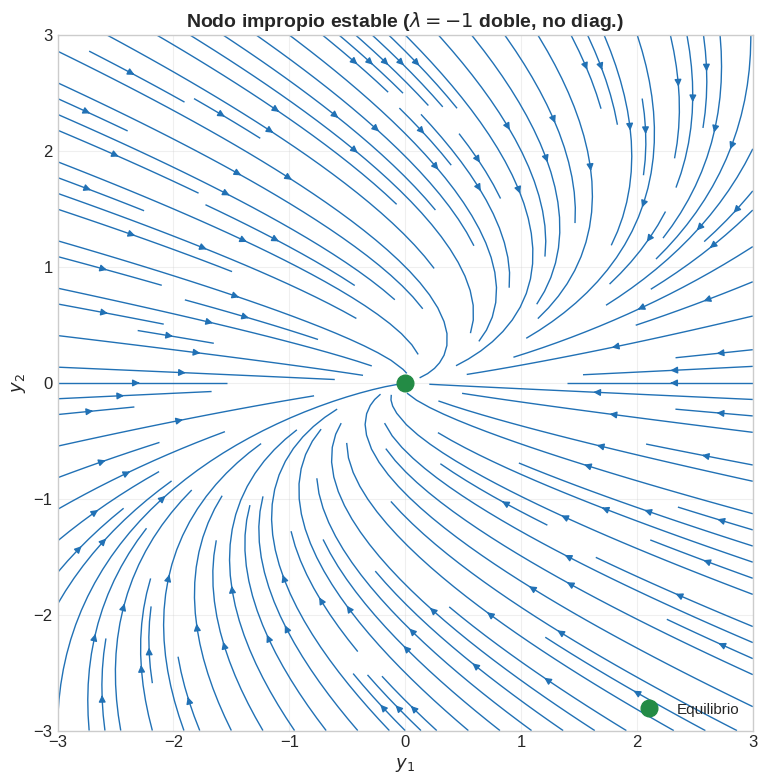

In [3]:
# Retrato de fase: nodo impropio (no diagonalizable)
fig, ax = plt.subplots(figsize=(8, 8))

A_imp = np.array([[-1, 1], [0, -1]])
Y, X = np.mgrid[-3:3:25j, -3:3:25j]
U = A_imp[0, 0] * X + A_imp[0, 1] * Y
V = A_imp[1, 0] * X + A_imp[1, 1] * Y

ax.streamplot(X, Y, U, V, color=COLOR_PRINCIPAL, density=1.5, linewidth=1)
ax.plot(0, 0, 'o', color=COLOR_PUNTO, ms=12, zorder=5, label=r'Equilibrio')
ax.set_title(r'Nodo impropio estable ($\lambda=-1$ doble, no diag.)', fontsize=14, fontweight='bold')
ax.set_xlabel(r'$y_1$')
ax.set_ylabel(r'$y_2$')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 5. No homogéneo: variación de parámetros

### 5.1 Fórmula general

Para $\mathbf{y}' = A\mathbf{y} + \mathbf{f}(t)$, si $Y(t)$ es la matriz fundamental del sistema homogéneo:

$$\boxed{\mathbf{y}_p(t) = Y(t)\int Y(t)^{-1}\mathbf{f}(t)\,dt}$$

Con condición inicial $\mathbf{y}(t_0) = \mathbf{y}_0$:

$$\mathbf{y}(t) = Y(t)Y(t_0)^{-1}\mathbf{y}_0 + Y(t)\int_{t_0}^{t} Y(s)^{-1}\mathbf{f}(s)\,ds$$

### 5.2 Pasos del método

1. Resolver el sistema homogéneo $\mathbf{y}' = A\mathbf{y}$ (obtener $Y(t)$)
2. Calcular $Y(t)^{-1}$
3. Calcular el producto $Y(t)^{-1}\mathbf{f}(t)$
4. Integrar componente a componente
5. Multiplicar por $Y(t)$

### 5.3 Ejemplo resuelto: variación de parámetros

Resolver $\mathbf{y}' = \begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix}\mathbf{y} + \begin{pmatrix} 0 \\ \sec(t) \end{pmatrix}$

**Paso 1:** Homogéneo. $\lambda = \pm i$, autovectores complejos $\to$ soluciones reales:

$$Y(t) = \begin{pmatrix} \cos t & \sin t \\ -\sin t & \cos t \end{pmatrix}$$

**Paso 2:** Como $Y(t)$ es la matriz de rotación, $Y(t)^{-1} = Y(t)^T$:

$$Y(t)^{-1} = \begin{pmatrix} \cos t & -\sin t \\ \sin t & \cos t \end{pmatrix}$$

**Paso 3:**

$$Y(t)^{-1}\mathbf{f}(t) = \begin{pmatrix} \cos t & -\sin t \\ \sin t & \cos t \end{pmatrix}\begin{pmatrix} 0 \\ \sec t \end{pmatrix} = \begin{pmatrix} -\tan t \\ 1 \end{pmatrix}$$

**Paso 4:** Integrar:

$$\int \begin{pmatrix} -\tan t \\ 1 \end{pmatrix}dt = \begin{pmatrix} \ln|\cos t| \\ t \end{pmatrix}$$

**Paso 5:** Solución particular:

$$\mathbf{y}_p(t) = Y(t)\begin{pmatrix} \ln|\cos t| \\ t \end{pmatrix} = \begin{pmatrix} \cos t \cdot \ln|\cos t| + t\sin t \\ -\sin t \cdot \ln|\cos t| + t\cos t \end{pmatrix}$$

$$\boxed{\mathbf{y}(t) = c_1\begin{pmatrix}\cos t\\-\sin t\end{pmatrix} + c_2\begin{pmatrix}\sin t\\\cos t\end{pmatrix} + \begin{pmatrix}\cos t\ln|\cos t| + t\sin t\\-\sin t\ln|\cos t| + t\cos t\end{pmatrix}}$$

---

## 6. No homogéneo: coeficientes indeterminados

### 6.1 Idea del método

Para $\mathbf{y}' = A\mathbf{y} + \mathbf{f}(t)$, se propone una solución particular $\mathbf{y}_p(t)$ con la **misma forma** que $\mathbf{f}(t)$, y se determinan los coeficientes sustituyendo en la EDO.

### 6.2 Tabla de soluciones tentativas

| $\mathbf{f}(t)$ | $\mathbf{y}_p(t)$ propuesta |
|----------|--------------------------|
| $\mathbf{a}$ (constante) | $\mathbf{c}$ (constante) |
| $\mathbf{a}e^{\mu t}$ ($\mu$ no autovalor) | $\mathbf{c}e^{\mu t}$ |
| $\mathbf{a}e^{\mu t}$ ($\mu$ autovalor simple) | $(\mathbf{c}_0 + \mathbf{c}_1 t)e^{\mu t}$ |
| $\mathbf{a}\cos(\omega t) + \mathbf{b}\sin(\omega t)$ | $\mathbf{c}\cos(\omega t) + \mathbf{d}\sin(\omega t)$ |
| $\mathbf{a}t^n$ | $\mathbf{c}_n t^n + \mathbf{c}_{n-1}t^{n-1} + \cdots + \mathbf{c}_0$ |

### 6.3 Ejemplo: $\mathbf{f}(t) = \begin{pmatrix} 1 \\ 0 \end{pmatrix}e^{2t}$

Con $A = \begin{pmatrix} 1 & 1 \\ 0 & -1 \end{pmatrix}$ (autovalores $1, -1$, ninguno es $2$).

Proponemos $\mathbf{y}_p = \mathbf{c}e^{2t}$. Sustituyendo: $2\mathbf{c}e^{2t} = A\mathbf{c}e^{2t} + \begin{pmatrix}1\\0\end{pmatrix}e^{2t}$.

$$(2I - A)\mathbf{c} = \begin{pmatrix}1\\0\end{pmatrix} \implies \begin{pmatrix}1&-1\\0&3\end{pmatrix}\mathbf{c} = \begin{pmatrix}1\\0\end{pmatrix} \implies \mathbf{c} = \begin{pmatrix}1\\0\end{pmatrix}$$

$$\boxed{\mathbf{y}_p(t) = \begin{pmatrix}1\\0\end{pmatrix}e^{2t}}$$

**Error frecuente:** Si $\mu$ coincide con un autovalor, la propuesta $\mathbf{c}e^{\mu t}$ **no funciona**. Hay que multiplicar por $t$.

---

## 7. No homogéneo: método de Laplace para sistemas

### 7.1 Procedimiento

Aplicando $\mathcal{L}$ a $\mathbf{y}' = A\mathbf{y} + \mathbf{f}(t)$ con $\mathbf{y}(0) = \mathbf{y}_0$:

$$s\mathbf{Y}(s) - \mathbf{y}_0 = A\mathbf{Y}(s) + \mathbf{F}(s)$$

$$(sI - A)\mathbf{Y}(s) = \mathbf{y}_0 + \mathbf{F}(s)$$

$$\boxed{\mathbf{Y}(s) = (sI - A)^{-1}[\mathbf{y}_0 + \mathbf{F}(s)]}$$

Luego se aplica $\mathcal{L}^{-1}$ componente a componente.

### 7.2 Ejemplo

Resolver $\begin{cases} x' = x + y \\ y' = -x + y \end{cases}$, $x(0) = 1$, $y(0) = 0$.

$A = \begin{pmatrix} 1 & 1 \\ -1 & 1 \end{pmatrix}$, $\mathbf{f}(t) = \mathbf{0}$, $\mathbf{y}_0 = \begin{pmatrix}1\\0\end{pmatrix}$.

**Paso 1:**

$$(sI - A) = \begin{pmatrix} s-1 & -1 \\ 1 & s-1 \end{pmatrix}, \quad \det = (s-1)^2 + 1$$

**Paso 2:**

$$(sI - A)^{-1} = \frac{1}{(s-1)^2+1}\begin{pmatrix} s-1 & 1 \\ -1 & s-1 \end{pmatrix}$$

**Paso 3:**

$$\mathbf{Y}(s) = \frac{1}{(s-1)^2+1}\begin{pmatrix} s-1 \\ -1 \end{pmatrix}$$

**Paso 4:** Transformada inversa:

$$X(s) = \frac{s-1}{(s-1)^2+1} \implies x(t) = e^t \cos t$$

$$Y(s) = \frac{-1}{(s-1)^2+1} \implies y(t) = -e^t \sin t$$

$$\boxed{\mathbf{y}(t) = e^t \begin{pmatrix} \cos t \\ -\sin t \end{pmatrix}}$$

---

## 8. Ejercicios resueltos con verificación numérica

#### Ejercicio resuelto 1: Sistema 2×2 con autovalores reales distintos

**Datos:** $x' = 4x - 3y$, $y' = 6x - 7y$, con $x(0) = 1$, $y(0) = 2$.

---

**Paso 1: Escribir la matriz del sistema.**

Identificamos los coeficientes del sistema:

$$\mathbf{y}' = A\mathbf{y}, \qquad A = \begin{pmatrix} 4 & -3 \\ 6 & -7 \end{pmatrix}$$

---

**Paso 2: Calcular los autovalores — escribir $\det(A - \lambda I) = 0$ explícitamente.**

$$A - \lambda I = \begin{pmatrix} 4 - \lambda & -3 \\ 6 & -7 - \lambda \end{pmatrix}$$

Calculamos el determinante:

$$\det(A - \lambda I) = (4 - \lambda)(-7 - \lambda) - (-3)(6)$$

Expandimos el primer producto paso a paso:

$$(4 - \lambda)(-7 - \lambda) = 4 \cdot (-7) + 4 \cdot (-\lambda) + (-\lambda)(-7) + (-\lambda)(-\lambda) = -28 - 4\lambda + 7\lambda + \lambda^2$$

$$= \lambda^2 + 3\lambda - 28$$

El segundo término: $(-3)(6) = -18$, así que $-(-3)(6) = +18$.

Juntando todo:

$$\det(A - \lambda I) = \lambda^2 + 3\lambda - 28 + 18 = \lambda^2 + 3\lambda - 10 = 0$$

Resolvemos con la fórmula cuadrática:

$$\lambda = \frac{-3 \pm \sqrt{9 + 40}}{2} = \frac{-3 \pm \sqrt{49}}{2} = \frac{-3 \pm 7}{2}$$

$$\boxed{\lambda_1 = \frac{-3 + 7}{2} = 2, \qquad \lambda_2 = \frac{-3 - 7}{2} = -5}$$

---

**Paso 3: Calcular el autovector para $\lambda_1 = 2$.**

Planteamos $(A - 2I)\mathbf{u}_1 = \mathbf{0}$:

$$A - 2I = \begin{pmatrix} 4-2 & -3 \\ 6 & -7-2 \end{pmatrix} = \begin{pmatrix} 2 & -3 \\ 6 & -9 \end{pmatrix}$$

Sistema aumentado:

$$\left(\begin{array}{cc|c} 2 & -3 & 0 \\ 6 & -9 & 0 \end{array}\right)$$

Reducción por filas: $F_2 \leftarrow F_2 - 3F_1$:

$$\left(\begin{array}{cc|c} 2 & -3 & 0 \\ 0 & 0 & 0 \end{array}\right)$$

De la primera fila: $2u_1 - 3u_2 = 0 \implies u_1 = \frac{3}{2}u_2$.

Tomamos $u_2 = 2$ para evitar fracciones:

$$\boxed{\mathbf{u}_1 = \begin{pmatrix} 3 \\ 2 \end{pmatrix}}$$

---

**Paso 4: Calcular el autovector para $\lambda_2 = -5$.**

Planteamos $(A - (-5)I)\mathbf{u}_2 = (A + 5I)\mathbf{u}_2 = \mathbf{0}$:

$$A + 5I = \begin{pmatrix} 4+5 & -3 \\ 6 & -7+5 \end{pmatrix} = \begin{pmatrix} 9 & -3 \\ 6 & -2 \end{pmatrix}$$

Sistema aumentado:

$$\left(\begin{array}{cc|c} 9 & -3 & 0 \\ 6 & -2 & 0 \end{array}\right)$$

Reducción: $F_2 \leftarrow F_2 - \frac{2}{3}F_1$:

$$\left(\begin{array}{cc|c} 9 & -3 & 0 \\ 0 & 0 & 0 \end{array}\right)$$

De la primera fila: $9u_1 - 3u_2 = 0 \implies u_1 = \frac{1}{3}u_2$.

Tomamos $u_2 = 3$:

$$\boxed{\mathbf{u}_2 = \begin{pmatrix} 1 \\ 3 \end{pmatrix}}$$

---

**Paso 5: Escribir la solución general.**

Con autovalores reales distintos, la solución general es:

$$\mathbf{y}(t) = c_1 e^{\lambda_1 t}\mathbf{u}_1 + c_2 e^{\lambda_2 t}\mathbf{u}_2 = c_1 e^{2t}\begin{pmatrix}3\\2\end{pmatrix} + c_2 e^{-5t}\begin{pmatrix}1\\3\end{pmatrix}$$

---

**Paso 6: Aplicar la condición inicial $\mathbf{y}(0) = \begin{pmatrix}1\\2\end{pmatrix}$.**

En $t = 0$: $e^0 = 1$, así que:

$$c_1 \begin{pmatrix}3\\2\end{pmatrix} + c_2 \begin{pmatrix}1\\3\end{pmatrix} = \begin{pmatrix}1\\2\end{pmatrix}$$

Esto da el sistema:

$$\begin{cases} 3c_1 + c_2 = 1 \\ 2c_1 + 3c_2 = 2 \end{cases}$$

De la primera ecuación: $c_2 = 1 - 3c_1$. Sustituyendo en la segunda:

$$2c_1 + 3(1 - 3c_1) = 2 \implies 2c_1 + 3 - 9c_1 = 2 \implies -7c_1 = -1 \implies c_1 = \frac{1}{7}$$

$$c_2 = 1 - 3 \cdot \frac{1}{7} = 1 - \frac{3}{7} = \frac{4}{7}$$

**Verificación rápida:** $3 \cdot \frac{1}{7} + \frac{4}{7} = \frac{3+4}{7} = 1$ ✓ y $2 \cdot \frac{1}{7} + 3 \cdot \frac{4}{7} = \frac{2+12}{7} = 2$ ✓

---

**Solución final:**

$$\boxed{\mathbf{y}(t) = \frac{1}{7}e^{2t}\begin{pmatrix}3\\2\end{pmatrix} + \frac{4}{7}e^{-5t}\begin{pmatrix}1\\3\end{pmatrix} = \begin{pmatrix} \frac{3}{7}e^{2t} + \frac{4}{7}e^{-5t} \\[6pt] \frac{2}{7}e^{2t} + \frac{12}{7}e^{-5t} \end{pmatrix}}$$

**Interpretación:** Como $\lambda_1 = 2 > 0$ y $\lambda_2 = -5 < 0$, el punto de equilibrio es un **punto de silla** (inestable). A largo plazo domina el término $e^{2t}$ y la solución crece en la dirección de $\mathbf{u}_1 = (3,2)^T$.

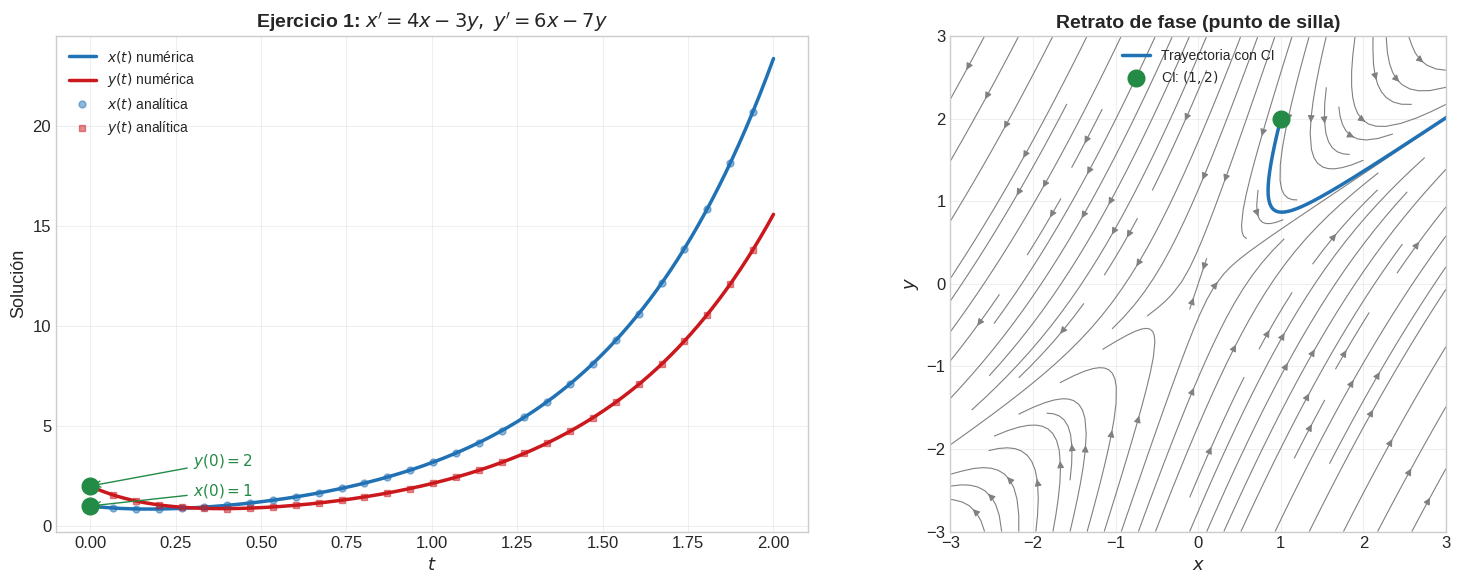

In [4]:
# Ejercicio 1: verificación numérica y gráfica
A1 = np.array([[4, -3], [6, -7]])
y0_1 = np.array([1.0, 2.0])

def sistema1(t, y):
    return A1 @ y

sol1 = solve_ivp(sistema1, [0, 2], y0_1, t_eval=np.linspace(0, 2, 300), dense_output=True)

# Solución analítica
t_an = sol1.t
c1, c2 = 1/7, 4/7
x_an = c1 * 3 * np.exp(2*t_an) + c2 * 1 * np.exp(-5*t_an)
y_an = c1 * 2 * np.exp(2*t_an) + c2 * 3 * np.exp(-5*t_an)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curvas x(t), y(t)
ax = axes[0]
ax.plot(sol1.t, sol1.y[0], color=COLOR_PRINCIPAL, lw=2.5, label=r'$x(t)$ numérica')
ax.plot(sol1.t, sol1.y[1], color=COLOR_RECTA, lw=2.5, label=r'$y(t)$ numérica')
ax.plot(t_an[::10], x_an[::10], 'o', color=COLOR_PRINCIPAL, ms=5, alpha=0.5, label=r'$x(t)$ analítica')
ax.plot(t_an[::10], y_an[::10], 's', color=COLOR_RECTA, ms=5, alpha=0.5, label=r'$y(t)$ analítica')
ax.plot(0, 1, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.plot(0, 2, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.annotate(r'$x(0)=1$', xy=(0, 1), xytext=(0.3, 1.5), fontsize=11,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO), color=COLOR_PUNTO)
ax.annotate(r'$y(0)=2$', xy=(0, 2), xytext=(0.3, 3), fontsize=11,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO), color=COLOR_PUNTO)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'Solución')
ax.set_title(r"Ejercicio 1: $x'=4x-3y,\; y'=6x-7y$", fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Retrato de fase
ax = axes[1]
Y_grid, X_grid = np.mgrid[-3:3:20j, -3:3:20j]
U = A1[0, 0] * X_grid + A1[0, 1] * Y_grid
V = A1[1, 0] * X_grid + A1[1, 1] * Y_grid
ax.streamplot(X_grid, Y_grid, U, V, color='gray', density=1, linewidth=0.8, arrowsize=1)
ax.plot(sol1.y[0], sol1.y[1], color=COLOR_PRINCIPAL, lw=2.5, label=r'Trayectoria con CI')
ax.plot(1, 2, 'o', color=COLOR_PUNTO, ms=12, zorder=5, label=r'CI: $(1, 2)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_title('Retrato de fase (punto de silla)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

#### Ejercicio resuelto 2: Sistema 3×3 diagonalizable

**Datos:** $\mathbf{y}' = A\mathbf{y}$ con $A = \begin{pmatrix} 1 & 0 & 0 \\ 0 & -1 & 2 \\ 0 & -2 & -1 \end{pmatrix}$, $\mathbf{y}(0) = \begin{pmatrix} 1 \\ 0 \\ 1 \end{pmatrix}$.

---

**Paso 1: Calcular los autovalores — escribir $\det(A - \lambda I) = 0$.**

$$A - \lambda I = \begin{pmatrix} 1-\lambda & 0 & 0 \\ 0 & -1-\lambda & 2 \\ 0 & -2 & -1-\lambda \end{pmatrix}$$

Como la primera fila tiene dos ceros, desarrollamos el determinante por la primera fila:

$$\det(A - \lambda I) = (1-\lambda) \cdot \det\begin{pmatrix} -1-\lambda & 2 \\ -2 & -1-\lambda \end{pmatrix}$$

Calculamos el determinante $2 \times 2$:

$$\det\begin{pmatrix} -1-\lambda & 2 \\ -2 & -1-\lambda \end{pmatrix} = (-1-\lambda)(-1-\lambda) - (2)(-2) = (-1-\lambda)^2 + 4$$

Expandimos $(-1-\lambda)^2$:

$$(-1-\lambda)^2 = 1 + 2\lambda + \lambda^2$$

Entonces:

$$(-1-\lambda)^2 + 4 = \lambda^2 + 2\lambda + 1 + 4 = \lambda^2 + 2\lambda + 5$$

El polinomio característico completo es:

$$(1-\lambda)(\lambda^2 + 2\lambda + 5) = 0$$

**Raíz real:** $1 - \lambda = 0 \implies \lambda_1 = 1$.

**Raíces complejas:** Aplicamos la fórmula cuadrática a $\lambda^2 + 2\lambda + 5 = 0$:

$$\lambda = \frac{-2 \pm \sqrt{4 - 20}}{2} = \frac{-2 \pm \sqrt{-16}}{2} = \frac{-2 \pm 4i}{2} = -1 \pm 2i$$

$$\boxed{\lambda_1 = 1, \qquad \lambda_{2,3} = -1 \pm 2i}$$

---

**Paso 2: Autovector para $\lambda_1 = 1$ (autovalor real).**

Planteamos $(A - I)\mathbf{u}_1 = \mathbf{0}$:

$$A - I = \begin{pmatrix} 0 & 0 & 0 \\ 0 & -2 & 2 \\ 0 & -2 & -2 \end{pmatrix}$$

De la segunda fila: $-2u_2 + 2u_3 = 0 \implies u_2 = u_3$.

De la tercera fila: $-2u_2 - 2u_3 = 0 \implies u_2 = -u_3$.

Combinando: $u_2 = u_3$ y $u_2 = -u_3$, lo que implica $u_2 = u_3 = 0$, y $u_1$ es libre.

Tomando $u_1 = 1$:

$$\boxed{\mathbf{u}_1 = \begin{pmatrix} 1 \\ 0 \\ 0 \end{pmatrix}}$$

---

**Paso 3: Autovector complejo para $\lambda_2 = -1 + 2i$.**

Planteamos $(A - (-1+2i)I)\mathbf{u} = \mathbf{0}$:

$$A - (-1+2i)I = \begin{pmatrix} 1-(-1+2i) & 0 & 0 \\ 0 & -1-(-1+2i) & 2 \\ 0 & -2 & -1-(-1+2i) \end{pmatrix} = \begin{pmatrix} 2-2i & 0 & 0 \\ 0 & -2i & 2 \\ 0 & -2 & -2i \end{pmatrix}$$

De la primera fila: $(2-2i)u_1 = 0 \implies u_1 = 0$.

De la segunda fila: $-2i \cdot u_2 + 2u_3 = 0 \implies u_3 = i \cdot u_2$.

Tomamos $u_2 = 1$, $u_3 = i$:

$$\mathbf{u} = \begin{pmatrix} 0 \\ 1 \\ i \end{pmatrix}$$

**Verificación con la tercera fila:** $-2(1) + (-2i)(i) = -2 + (-2i^2) = -2 + 2 = 0$ ✓

---

**Paso 4: Separar el autovector complejo en partes real e imaginaria.**

$$\mathbf{u} = \begin{pmatrix} 0 \\ 1 \\ i \end{pmatrix} = \underbrace{\begin{pmatrix} 0 \\ 1 \\ 0 \end{pmatrix}}_{\mathbf{v} \text{ (parte real)}} + i\underbrace{\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}}_{\mathbf{w} \text{ (parte imaginaria)}}$$

---

**Paso 5: Construir las dos soluciones reales a partir del par complejo.**

Con $\alpha = -1$, $\beta = 2$, las dos soluciones reales linealmente independientes son:

$$\mathbf{y}_2(t) = e^{\alpha t}[\mathbf{v}\cos(\beta t) - \mathbf{w}\sin(\beta t)] = e^{-t}\left[\begin{pmatrix}0\\1\\0\end{pmatrix}\cos 2t - \begin{pmatrix}0\\0\\1\end{pmatrix}\sin 2t\right] = e^{-t}\begin{pmatrix}0\\\cos 2t\\-\sin 2t\end{pmatrix}$$

$$\mathbf{y}_3(t) = e^{\alpha t}[\mathbf{v}\sin(\beta t) + \mathbf{w}\cos(\beta t)] = e^{-t}\left[\begin{pmatrix}0\\1\\0\end{pmatrix}\sin 2t + \begin{pmatrix}0\\0\\1\end{pmatrix}\cos 2t\right] = e^{-t}\begin{pmatrix}0\\\sin 2t\\\cos 2t\end{pmatrix}$$

---

**Paso 6: Escribir la solución general.**

$$\mathbf{y}(t) = c_1 e^{t}\begin{pmatrix}1\\0\\0\end{pmatrix} + c_2 e^{-t}\begin{pmatrix}0\\\cos 2t\\-\sin 2t\end{pmatrix} + c_3 e^{-t}\begin{pmatrix}0\\\sin 2t\\\cos 2t\end{pmatrix}$$

---

**Paso 7: Aplicar la condición inicial $\mathbf{y}(0) = (1, 0, 1)^T$.**

En $t = 0$: $e^0 = 1$, $\cos 0 = 1$, $\sin 0 = 0$:

$$c_1\begin{pmatrix}1\\0\\0\end{pmatrix} + c_2\begin{pmatrix}0\\1\\0\end{pmatrix} + c_3\begin{pmatrix}0\\0\\1\end{pmatrix} = \begin{pmatrix}1\\0\\1\end{pmatrix}$$

Esto da directamente:

$$c_1 = 1, \qquad c_2 = 0, \qquad c_3 = 1$$

---

**Solución final:**

$$\boxed{\mathbf{y}(t) = \begin{pmatrix} e^t \\ e^{-t}\sin 2t \\ e^{-t}\cos 2t \end{pmatrix}}$$

**Interpretación:** La primera componente crece exponencialmente ($\lambda_1 = 1 > 0$), mientras que las componentes 2 y 3 oscilan con amplitud decreciente ($\alpha = -1 < 0$). El equilibrio es **inestable** porque existe al menos un autovalor con parte real positiva.

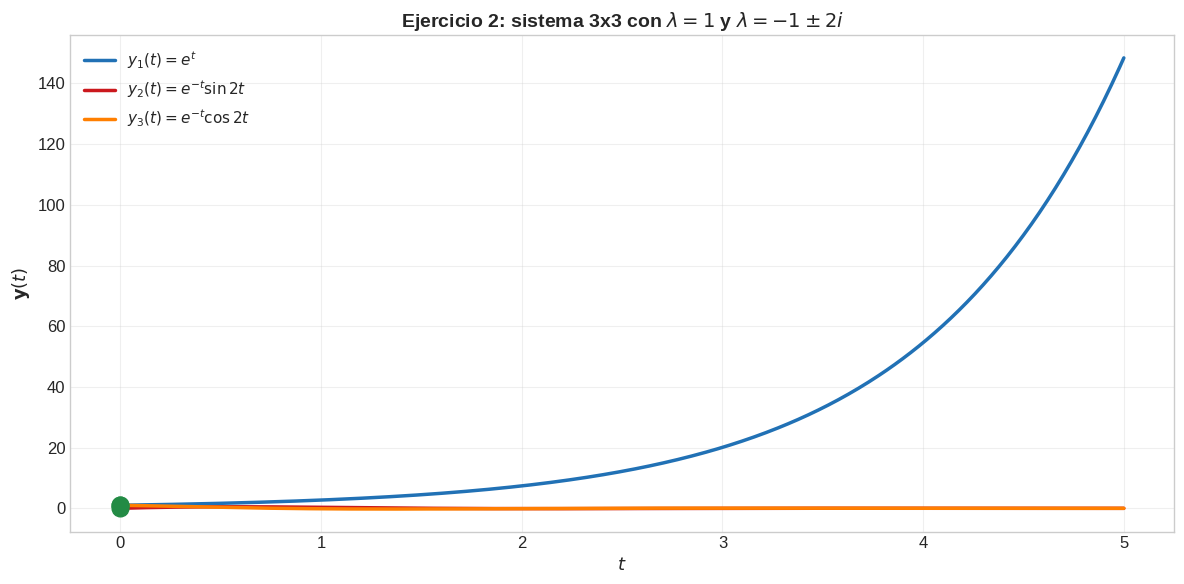

In [5]:
# Ejercicio 2: sistema 3x3 con autovalores complejos
A2 = np.array([[1, 0, 0], [0, -1, 2], [0, -2, -1]])
y0_2 = np.array([1.0, 0.0, 1.0])

sol2 = solve_ivp(lambda t, y: A2 @ y, [0, 5], y0_2, t_eval=np.linspace(0, 5, 500))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sol2.t, sol2.y[0], color=COLOR_PRINCIPAL, lw=2.5, label=r'$y_1(t) = e^t$')
ax.plot(sol2.t, sol2.y[1], color=COLOR_RECTA, lw=2.5, label=r'$y_2(t) = e^{-t}\sin 2t$')
ax.plot(sol2.t, sol2.y[2], color=COLOR_AUX, lw=2.5, label=r'$y_3(t) = e^{-t}\cos 2t$')
ax.plot(0, 1, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.plot(0, 0, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.plot(0, 1, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\mathbf{y}(t)$')
ax.set_title(r'Ejercicio 2: sistema 3x3 con $\lambda=1$ y $\lambda=-1\pm 2i$', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Ejercicio resuelto 3: Sistema 2×2 no diagonalizable

**Datos:** $\mathbf{y}' = \begin{pmatrix} 3 & 1 \\ 0 & 3 \end{pmatrix}\mathbf{y}$, $\mathbf{y}(0) = \begin{pmatrix}1\\2\end{pmatrix}$.

---

**Paso 1: Calcular los autovalores.**

$$A - \lambda I = \begin{pmatrix} 3-\lambda & 1 \\ 0 & 3-\lambda \end{pmatrix}$$

$$\det(A - \lambda I) = (3-\lambda)(3-\lambda) - (1)(0) = (3-\lambda)^2 = 0$$

$$\boxed{\lambda = 3 \text{ (doble)}}$$

---

**Paso 2: Verificar si es diagonalizable o no.**

Calculamos $A - 3I$:

$$A - 3I = \begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix}$$

Como $A - 3I \neq 0$ (la matriz no es la matriz cero), **no es diagonalizable** (si fuera diagonalizable con $\lambda$ doble, necesitaríamos $A - \lambda I = 0$, es decir $A = \lambda I$).

El rango de $(A - 3I)$ es 1, así que el espacio propio tiene dimensión $2 - 1 = 1$ (solo un autovector linealmente independiente). Confirmado: **tipo 3 (nodo impropio)**.

---

**Paso 3: Encontrar el autovector $\mathbf{u}$.**

Resolvemos $(A - 3I)\mathbf{u} = \mathbf{0}$:

$$\begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix}\begin{pmatrix}u_1\\u_2\end{pmatrix} = \begin{pmatrix}0\\0\end{pmatrix}$$

De la primera fila: $u_2 = 0$. La variable $u_1$ es libre.

Tomando $u_1 = 1$:

$$\boxed{\mathbf{u} = \begin{pmatrix}1\\0\end{pmatrix}}$$

---

**Paso 4: Encontrar el vector generalizado $\mathbf{w}$.**

Resolvemos $(A - 3I)\mathbf{w} = \mathbf{u}$:

$$\begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix}\begin{pmatrix}w_1\\w_2\end{pmatrix} = \begin{pmatrix}1\\0\end{pmatrix}$$

De la primera fila: $w_2 = 1$.

De la segunda fila: $0 = 0$ (se cumple automáticamente).

La variable $w_1$ es libre. Tomamos $w_1 = 0$ (la elección más simple):

$$\boxed{\mathbf{w} = \begin{pmatrix}0\\1\end{pmatrix}}$$

---

**Paso 5: Escribir las dos soluciones linealmente independientes.**

Para un autovalor doble no diagonalizable, las dos soluciones son:

$$\mathbf{y}_1(t) = e^{\lambda t}\mathbf{u} = e^{3t}\begin{pmatrix}1\\0\end{pmatrix}$$

$$\mathbf{y}_2(t) = e^{\lambda t}(t\mathbf{u} + \mathbf{w}) = e^{3t}\left[t\begin{pmatrix}1\\0\end{pmatrix} + \begin{pmatrix}0\\1\end{pmatrix}\right] = e^{3t}\begin{pmatrix}t\\1\end{pmatrix}$$

---

**Paso 6: Escribir la solución general.**

$$\mathbf{y}(t) = c_1 e^{3t}\begin{pmatrix}1\\0\end{pmatrix} + c_2 e^{3t}\begin{pmatrix}t\\1\end{pmatrix} = e^{3t}\begin{pmatrix}c_1 + c_2 t\\c_2\end{pmatrix}$$

---

**Paso 7: Aplicar la condición inicial $\mathbf{y}(0) = (1, 2)^T$.**

En $t = 0$:

$$e^{0}\begin{pmatrix}c_1 + c_2 \cdot 0\\c_2\end{pmatrix} = \begin{pmatrix}c_1\\c_2\end{pmatrix} = \begin{pmatrix}1\\2\end{pmatrix}$$

Por tanto: $c_1 = 1$, $c_2 = 2$.

---

**Solución final:**

$$\boxed{\mathbf{y}(t) = e^{3t}\begin{pmatrix}1 + 2t\\2\end{pmatrix}}$$

Comprobando componente a componente: $x(t) = e^{3t}(1+2t)$, $y(t) = 2e^{3t}$.

**Verificación:** $x' = 3e^{3t}(1+2t) + 2e^{3t} = e^{3t}(3+6t+2) = e^{3t}(5+6t)$. Por otro lado, $3x + y = 3e^{3t}(1+2t) + 2e^{3t} = e^{3t}(3+6t+2) = e^{3t}(5+6t)$ ✓

**Interpretación:** Como $\lambda = 3 > 0$, el equilibrio es un **nodo impropio inestable**. Todas las trayectorias se alejan del origen tangentes a la dirección del autovector $\mathbf{u} = (1,0)^T$.

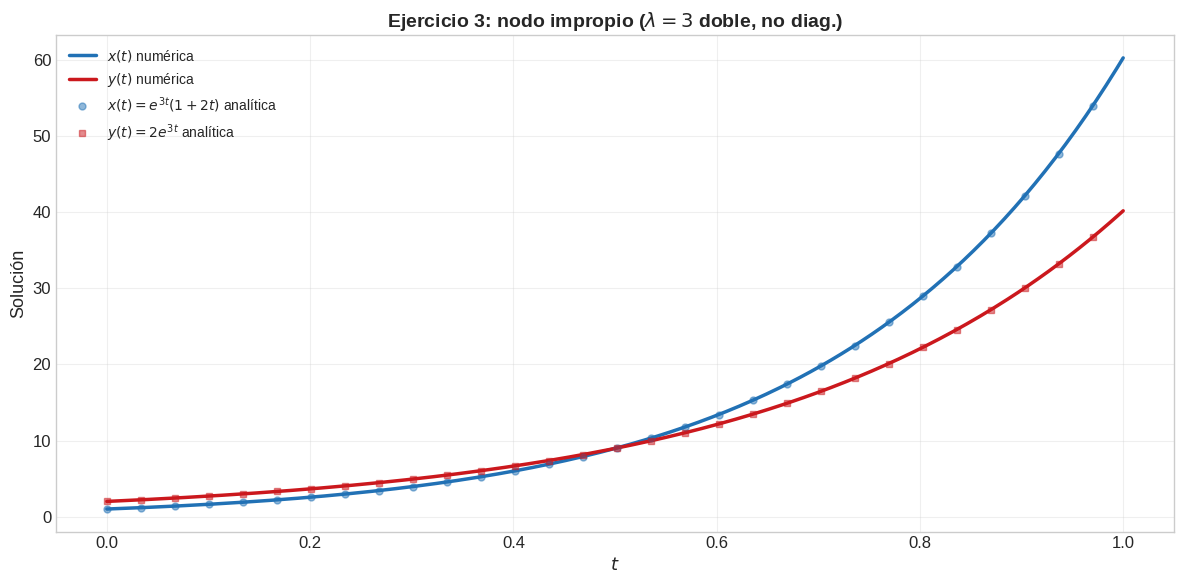

In [6]:
# Ejercicio 3: 2x2 no diagonalizable
A3 = np.array([[3, 1], [0, 3]])
y0_3 = np.array([1.0, 2.0])

sol3 = solve_ivp(lambda t, y: A3 @ y, [0, 1], y0_3, t_eval=np.linspace(0, 1, 300))

# Solución analítica
t3 = sol3.t
x3_an = np.exp(3*t3) * (1 + 2*t3)
y3_an = 2 * np.exp(3*t3)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sol3.t, sol3.y[0], color=COLOR_PRINCIPAL, lw=2.5, label=r'$x(t)$ numérica')
ax.plot(sol3.t, sol3.y[1], color=COLOR_RECTA, lw=2.5, label=r'$y(t)$ numérica')
ax.plot(t3[::10], x3_an[::10], 'o', color=COLOR_PRINCIPAL, ms=5, alpha=0.5, label=r'$x(t)=e^{3t}(1+2t)$ analítica')
ax.plot(t3[::10], y3_an[::10], 's', color=COLOR_RECTA, ms=5, alpha=0.5, label=r'$y(t)=2e^{3t}$ analítica')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'Solución')
ax.set_title(r'Ejercicio 3: nodo impropio ($\lambda=3$ doble, no diag.)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Ejercicio resuelto 4: Sistema no homogéneo (variación de parámetros)

**Datos:** $\mathbf{y}' = \begin{pmatrix} 0 & 1 \\ -2 & -3 \end{pmatrix}\mathbf{y} + \begin{pmatrix} 0 \\ e^{-t} \end{pmatrix}$, $\mathbf{y}(0) = \begin{pmatrix}0\\0\end{pmatrix}$.

---

**Paso 1: Resolver el sistema homogéneo — calcular autovalores de $A$.**

$$A - \lambda I = \begin{pmatrix} -\lambda & 1 \\ -2 & -3-\lambda \end{pmatrix}$$

$$\det(A - \lambda I) = (-\lambda)(-3-\lambda) - (1)(-2) = 3\lambda + \lambda^2 + 2 = \lambda^2 + 3\lambda + 2 = 0$$

Factorizamos: $\lambda^2 + 3\lambda + 2 = (\lambda + 1)(\lambda + 2) = 0$.

$$\boxed{\lambda_1 = -1, \qquad \lambda_2 = -2}$$

---

**Paso 2: Calcular los autovectores.**

**Para $\lambda_1 = -1$:** $(A + I)\mathbf{u}_1 = \mathbf{0}$:

$$A + I = \begin{pmatrix} 1 & 1 \\ -2 & -2 \end{pmatrix}$$

$F_2 \leftarrow F_2 + 2F_1$: $\begin{pmatrix} 1 & 1 \\ 0 & 0 \end{pmatrix}$

De la primera fila: $u_1 + u_2 = 0 \implies u_1 = -u_2$. Tomando $u_2 = -1$:

$$\mathbf{u}_1 = \begin{pmatrix}1\\-1\end{pmatrix}$$

**Para $\lambda_2 = -2$:** $(A + 2I)\mathbf{u}_2 = \mathbf{0}$:

$$A + 2I = \begin{pmatrix} 2 & 1 \\ -2 & -1 \end{pmatrix}$$

$F_2 \leftarrow F_2 + F_1$: $\begin{pmatrix} 2 & 1 \\ 0 & 0 \end{pmatrix}$

De la primera fila: $2u_1 + u_2 = 0 \implies u_2 = -2u_1$. Tomando $u_1 = 1$:

$$\mathbf{u}_2 = \begin{pmatrix}1\\-2\end{pmatrix}$$

---

**Paso 3: Construir la matriz fundamental $Y(t)$.**

$$Y(t) = \begin{pmatrix} e^{-t}\mathbf{u}_1 & e^{-2t}\mathbf{u}_2 \end{pmatrix} = \begin{pmatrix} e^{-t} & e^{-2t} \\ -e^{-t} & -2e^{-2t} \end{pmatrix}$$

---

**Paso 4: Calcular $Y(t)^{-1}$ usando la fórmula para matrices $2 \times 2$.**

Recordemos: si $M = \begin{pmatrix}a&b\\c&d\end{pmatrix}$, entonces $M^{-1} = \frac{1}{ad-bc}\begin{pmatrix}d&-b\\-c&a\end{pmatrix}$.

Primero, el determinante de $Y(t)$:

$$\det Y(t) = (e^{-t})(-2e^{-2t}) - (e^{-2t})(-e^{-t}) = -2e^{-3t} + e^{-3t} = -e^{-3t}$$

Aplicamos la fórmula:

$$Y(t)^{-1} = \frac{1}{-e^{-3t}}\begin{pmatrix} -2e^{-2t} & -e^{-2t} \\ -(-e^{-t}) & e^{-t} \end{pmatrix} = -e^{3t}\begin{pmatrix} -2e^{-2t} & -e^{-2t} \\ e^{-t} & e^{-t} \end{pmatrix}$$

Multiplicamos $-e^{3t}$ por cada entrada:

$$Y(t)^{-1} = \begin{pmatrix} 2e^{3t} \cdot e^{-2t} & e^{3t} \cdot e^{-2t} \\ -e^{3t} \cdot e^{-t} & -e^{3t} \cdot e^{-t} \end{pmatrix} = \begin{pmatrix} 2e^{t} & e^{t} \\ -e^{2t} & -e^{2t} \end{pmatrix}$$

---

**Paso 5: Calcular $Y(t)^{-1}\mathbf{f}(t)$.**

$$Y(t)^{-1}\mathbf{f}(t) = \begin{pmatrix} 2e^{t} & e^{t} \\ -e^{2t} & -e^{2t} \end{pmatrix}\begin{pmatrix} 0 \\ e^{-t} \end{pmatrix}$$

Primera componente: $2e^t \cdot 0 + e^t \cdot e^{-t} = 0 + e^0 = 1$.

Segunda componente: $-e^{2t} \cdot 0 + (-e^{2t}) \cdot e^{-t} = 0 - e^{t} = -e^t$.

$$Y(t)^{-1}\mathbf{f}(t) = \begin{pmatrix} 1 \\ -e^{t} \end{pmatrix}$$

---

**Paso 6: Integrar cada componente de 0 a $t$.**

$$\int_0^t Y(s)^{-1}\mathbf{f}(s)\,ds = \int_0^t \begin{pmatrix} 1 \\ -e^{s} \end{pmatrix}ds = \begin{pmatrix} \int_0^t 1\,ds \\ \int_0^t -e^{s}\,ds \end{pmatrix} = \begin{pmatrix} t \\ -(e^t - 1) \end{pmatrix} = \begin{pmatrix} t \\ -e^t + 1 \end{pmatrix}$$

---

**Paso 7: Calcular la solución particular $\mathbf{y}_p(t) = Y(t) \cdot \int_0^t Y(s)^{-1}\mathbf{f}(s)\,ds$.**

$$\mathbf{y}_p(t) = \begin{pmatrix} e^{-t} & e^{-2t} \\ -e^{-t} & -2e^{-2t} \end{pmatrix}\begin{pmatrix} t \\ -e^t + 1 \end{pmatrix}$$

**Primera componente:**

$$e^{-t} \cdot t + e^{-2t} \cdot (-e^t + 1) = te^{-t} - e^{-2t} \cdot e^t + e^{-2t} \cdot 1 = te^{-t} - e^{-t} + e^{-2t}$$

**Segunda componente:**

$$(-e^{-t}) \cdot t + (-2e^{-2t}) \cdot (-e^t + 1) = -te^{-t} + 2e^{-2t} \cdot e^t - 2e^{-2t} = -te^{-t} + 2e^{-t} - 2e^{-2t}$$

$$\mathbf{y}_p(t) = \begin{pmatrix} te^{-t} - e^{-t} + e^{-2t} \\ -te^{-t} + 2e^{-t} - 2e^{-2t} \end{pmatrix}$$

---

**Paso 8: Verificar la condición inicial.**

Como usamos la integral definida de 0 a $t$, la condición inicial ya está incorporada. Verifiquemos:

$$\mathbf{y}_p(0) = \begin{pmatrix} 0 \cdot 1 - 1 + 1 \\ 0 \cdot 1 + 2 - 2 \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \end{pmatrix} = \mathbf{y}_0 \quad \checkmark$$

No necesitamos sumar la solución homogénea con constantes adicionales porque la CI ya se satisface.

---

**Solución final:**

$$\boxed{\mathbf{y}(t) = \begin{pmatrix} te^{-t} - e^{-t} + e^{-2t} \\ -te^{-t} + 2e^{-t} - 2e^{-2t} \end{pmatrix}}$$

**Verificación rápida de $x(0)$ y $y(0)$:** ambos dan 0 ✓

**Interpretación:** Los autovalores $\lambda_1 = -1$, $\lambda_2 = -2$ son ambos negativos, por lo que el sistema homogéneo tiene un nodo estable. La solución del sistema no homogéneo tiende a $\mathbf{0}$ cuando $t \to \infty$ porque tanto la homogénea como la particular decaen (el forzamiento $e^{-t}$ también decae).

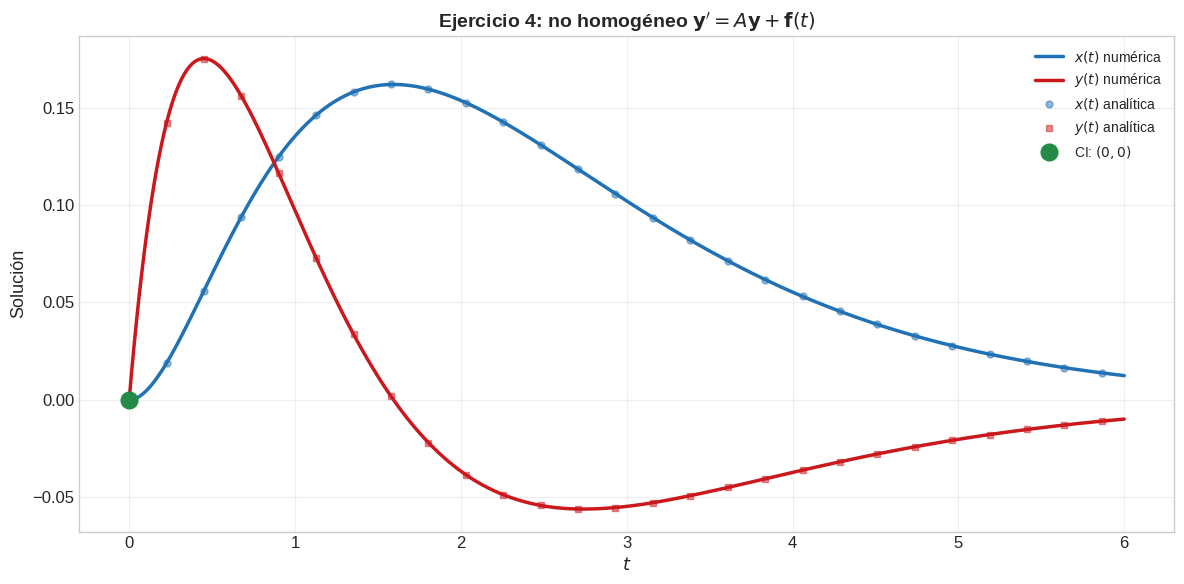

In [7]:
# Ejercicio 4: no homogéneo con variación de parámetros
A4 = np.array([[0, 1], [-2, -3]])
y0_4 = np.array([0.0, 0.0])

def sistema4(t, y):
    return A4 @ y + np.array([0, np.exp(-t)])

sol4 = solve_ivp(sistema4, [0, 6], y0_4, t_eval=np.linspace(0, 6, 400))

# Solución analítica
t4 = sol4.t
x4_an = t4 * np.exp(-t4) - np.exp(-t4) + np.exp(-2*t4)
y4_an = -t4 * np.exp(-t4) + 2*np.exp(-t4) - 2*np.exp(-2*t4)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sol4.t, sol4.y[0], color=COLOR_PRINCIPAL, lw=2.5, label=r'$x(t)$ numérica')
ax.plot(sol4.t, sol4.y[1], color=COLOR_RECTA, lw=2.5, label=r'$y(t)$ numérica')
ax.plot(t4[::15], x4_an[::15], 'o', color=COLOR_PRINCIPAL, ms=5, alpha=0.5, label=r'$x(t)$ analítica')
ax.plot(t4[::15], y4_an[::15], 's', color=COLOR_RECTA, ms=5, alpha=0.5, label=r'$y(t)$ analítica')
ax.plot(0, 0, 'o', color=COLOR_PUNTO, ms=12, zorder=5, label=r'CI: $(0,0)$')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'Solución')
ax.set_title(r"Ejercicio 4: no homogéneo $\mathbf{y}'=A\mathbf{y}+\mathbf{f}(t)$", fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 9. Catálogo completo de ejercicios: todos los patrones

| # | Tipo | Método | Ecuación clave | Dificultad |
|---|------|--------|----------------|------------|
| 1 | 2×2 autovalores reales distintos | Diagonalización | $\mathbf{y}=\sum c_i e^{\lambda_i t}\mathbf{u}_i$ | Media |
| 2 | 2×2 autovalor repetido diagonalizable | Nodo estrella | $\mathbf{y}=e^{\lambda t}(c_1\mathbf{u}_1+c_2\mathbf{u}_2)$ | Baja |
| 3 | 2×2 autovalor repetido NO diagonalizable | Jordan / cadena | $\mathbf{y}_2=e^{\lambda t}(t\mathbf{u}+\mathbf{w})$ | Alta |
| 4 | 2×2 autovalores complejos conjugados | Euler | $e^{\alpha t}[\mathbf{v}\cos\beta t-\mathbf{w}\sin\beta t]$ | Media |
| 5 | 3×3 diagonalizable (mixto real/complejo) | Diagonalización | Combinar tipos 1 y 4 | Alta |
| 6 | No homogéneo: variación de parámetros | $Y(t)\int Y^{-1}\mathbf{f}\,dt$ | Inversión de $Y(t)$ | Alta |
| 7 | No homogéneo: coeficientes indeterminados | Propuesta + sustitución | $(\mu I - A)\mathbf{c}=\mathbf{b}$ | Media |
| 8 | No homogéneo: Laplace | $(sI-A)^{-1}$ | Fracciones parciales | Alta |
| 9 | Clasificar punto de equilibrio | Traza + determinante | $\text{tr}(A)$, $\det(A)$, $\Delta$ | Baja |
| 10 | Reducción de orden $n$ a sistema | Variables de estado | Matriz compañera | Baja |

### 9.1 Tipo 1: 2×2 con autovalores reales distintos

$$\boxed{\mathbf{y}(t) = c_1 e^{\lambda_1 t}\mathbf{u}_1 + c_2 e^{\lambda_2 t}\mathbf{u}_2}$$

**Procedimiento detallado paso a paso:**

**Paso 1: Escribir la ecuación característica $\det(A - \lambda I) = 0$.**

Para $A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$:

$$\det\begin{pmatrix} a-\lambda & b \\ c & d-\lambda \end{pmatrix} = (a-\lambda)(d-\lambda) - bc = 0$$

Expandir: $\lambda^2 - (a+d)\lambda + (ad - bc) = 0$, es decir $\lambda^2 - \text{tr}(A)\lambda + \det(A) = 0$.

Resolver con la fórmula cuadrática: $\lambda = \frac{\text{tr}(A) \pm \sqrt{\text{tr}(A)^2 - 4\det(A)}}{2}$.

Este tipo corresponde al caso $\Delta = \text{tr}(A)^2 - 4\det(A) > 0$ (discriminante positivo, dos raíces reales distintas).

**Paso 2: Para cada autovalor $\lambda_i$, plantear $(A - \lambda_i I)\mathbf{u}_i = \mathbf{0}$ y reducir.**

Ejemplo concreto: si $\lambda_1 = 2$ y $A = \begin{pmatrix}4&-3\\6&-7\end{pmatrix}$:

$$A - 2I = \begin{pmatrix}2&-3\\6&-9\end{pmatrix} \xrightarrow{F_2 - 3F_1} \begin{pmatrix}2&-3\\0&0\end{pmatrix}$$

De la primera fila: $2u_1 = 3u_2$. Elegir $u_2$ para evitar fracciones: $u_2 = 2 \implies u_1 = 3$, dando $\mathbf{u}_1 = (3,2)^T$.

**Paso 3: Escribir la solución general** con las dos soluciones linealmente independientes $e^{\lambda_1 t}\mathbf{u}_1$ y $e^{\lambda_2 t}\mathbf{u}_2$.

**Paso 4: Aplicar CI.** En $t = 0$ las exponenciales valen 1, obteniendo el sistema:

$$\begin{pmatrix} | & | \\ \mathbf{u}_1 & \mathbf{u}_2 \\ | & | \end{pmatrix}\begin{pmatrix}c_1\\c_2\end{pmatrix} = \mathbf{y}_0$$

Resolver por sustitución, Cramer o eliminación gaussiana.

---

**Clasificación del equilibrio:**
- $\lambda_1, \lambda_2 < 0$ $\to$ **nodo estable** (todas las trayectorias convergen al origen)
- $\lambda_1, \lambda_2 > 0$ $\to$ **nodo inestable** (todas divergen)
- $\lambda_1 \cdot \lambda_2 < 0$ $\to$ **punto de silla** (inestable; las trayectorias se acercan por una dirección y se alejan por otra)

**Errores frecuentes:**
- Olvidar el signo al calcular $-bc$ en el determinante
- No simplificar el autovector (cualquier múltiplo escalar no nulo es válido)
- Al aplicar CI, resolver mal el sistema $2 \times 2$

### 9.2 Tipo 2: 2×2 con autovalor repetido diagonalizable (nodo estrella)

Ocurre cuando $A = \lambda I$ (caso raro pero posible en examen).

$$\boxed{\mathbf{y}(t) = e^{\lambda t}(c_1\mathbf{e}_1 + c_2\mathbf{e}_2) = e^{\lambda t}\mathbf{y}_0}$$

**Procedimiento detallado paso a paso:**

**Paso 1: Calcular $\det(A - \lambda I) = 0$.**

Se obtiene $(\lambda_0)^2 = 0$, es decir un autovalor doble $\lambda = \lambda_0$.

**Paso 2: Verificar que es diagonalizable.** Calcular $A - \lambda_0 I$:

- Si $A - \lambda_0 I = \begin{pmatrix}0&0\\0&0\end{pmatrix}$ (la matriz cero), entonces **sí es diagonalizable** (tipo 2, nodo estrella).
- Si $A - \lambda_0 I \neq 0$, es **no diagonalizable** (tipo 3, nodo impropio). Ir a la sección 9.3.

**Paso 3: Cuando $A = \lambda_0 I$, cualquier vector no nulo es autovector.** Podemos usar la base canónica:

$$\mathbf{e}_1 = \begin{pmatrix}1\\0\end{pmatrix}, \qquad \mathbf{e}_2 = \begin{pmatrix}0\\1\end{pmatrix}$$

**Paso 4: Solución general:**

$$\mathbf{y}(t) = c_1 e^{\lambda_0 t}\begin{pmatrix}1\\0\end{pmatrix} + c_2 e^{\lambda_0 t}\begin{pmatrix}0\\1\end{pmatrix} = e^{\lambda_0 t}\begin{pmatrix}c_1\\c_2\end{pmatrix}$$

**Paso 5: Aplicar CI.** En $t=0$: $\begin{pmatrix}c_1\\c_2\end{pmatrix} = \mathbf{y}_0$, así que la solución es simplemente:

$$\mathbf{y}(t) = e^{\lambda_0 t}\mathbf{y}_0$$

---

**Ejemplo concreto:** $A = \begin{pmatrix}-3&0\\0&-3\end{pmatrix}$, $\mathbf{y}_0 = \begin{pmatrix}2\\-1\end{pmatrix}$.

$\det(A-\lambda I) = (-3-\lambda)^2 = 0 \implies \lambda = -3$ (doble).

$A - (-3)I = \begin{pmatrix}0&0\\0&0\end{pmatrix} = 0$. Es tipo 2.

$$\mathbf{y}(t) = e^{-3t}\begin{pmatrix}2\\-1\end{pmatrix}$$

---

**Truco:** La exponencial matricial es simplemente $e^{At} = e^{\lambda_0 t}I$, así que $\mathbf{y}(t) = e^{\lambda_0 t}I \cdot \mathbf{y}_0 = e^{\lambda_0 t}\mathbf{y}_0$.

**Geometría:** Todas las trayectorias son **rectas** que pasan por el origen (de ahí el nombre "nodo estrella"). Si $\lambda_0 < 0$, convergen al origen; si $\lambda_0 > 0$, divergen.

### 9.3 Tipo 3: 2×2 con autovalor repetido NO diagonalizable

$$\boxed{\begin{aligned} \mathbf{y}_1(t) &= e^{\lambda t}\mathbf{u} \\ \mathbf{y}_2(t) &= e^{\lambda t}(t\mathbf{u} + \mathbf{w}) \end{aligned}}$$

donde $\mathbf{u}$ es el autovector y $\mathbf{w}$ es el vector generalizado que satisface $(A - \lambda I)\mathbf{w} = \mathbf{u}$.

**Procedimiento detallado paso a paso:**

**Paso 1: Calcular el autovalor doble $\lambda$.**

$\det(A-\lambda I) = 0$ da $\lambda$ con multiplicidad algebraica 2.

**Paso 2: Verificar que NO es diagonalizable.**

Calcular $A - \lambda I$. Si el resultado es **distinto de la matriz cero** (tiene rango 1), entonces es tipo 3.

El espacio propio tiene dimensión $2 - \text{rango}(A-\lambda I) = 2 - 1 = 1$: solo un autovector independiente.

**Paso 3: Encontrar el autovector $\mathbf{u}$.**

Resolver $(A - \lambda I)\mathbf{u} = \mathbf{0}$. Como el rango es 1, una fila es proporcional a la otra. De cualquier fila no nula se obtiene la relación entre $u_1$ y $u_2$.

*Ejemplo:* Si $A - \lambda I = \begin{pmatrix}0&1\\0&0\end{pmatrix}$, de la primera fila: $u_2 = 0$, $u_1$ libre $\implies \mathbf{u} = \begin{pmatrix}1\\0\end{pmatrix}$.

**Paso 4: Encontrar el vector generalizado $\mathbf{w}$.**

Resolver $(A - \lambda I)\mathbf{w} = \mathbf{u}$:

$$\begin{pmatrix} \alpha & \beta \\ \gamma & \delta \end{pmatrix}\begin{pmatrix}w_1\\w_2\end{pmatrix} = \begin{pmatrix}u_1\\u_2\end{pmatrix}$$

Como el rango es 1, una ecuación es redundante. Hay una variable libre; elegir el valor más simple (generalmente 0).

*Ejemplo:* $\begin{pmatrix}0&1\\0&0\end{pmatrix}\begin{pmatrix}w_1\\w_2\end{pmatrix} = \begin{pmatrix}1\\0\end{pmatrix}$. De la primera fila: $w_2 = 1$. $w_1$ es libre, tomamos $w_1 = 0$: $\mathbf{w} = \begin{pmatrix}0\\1\end{pmatrix}$.

**Paso 5: Escribir las dos soluciones linealmente independientes:**

$$\mathbf{y}_1(t) = e^{\lambda t}\mathbf{u}, \qquad \mathbf{y}_2(t) = e^{\lambda t}(t\mathbf{u} + \mathbf{w})$$

**Paso 6: Solución general:**

$$\mathbf{y}(t) = c_1\mathbf{y}_1(t) + c_2\mathbf{y}_2(t) = e^{\lambda t}[(c_1 + c_2 t)\mathbf{u} + c_2\mathbf{w}]$$

**Paso 7: Aplicar CI.** En $t=0$: $c_1\mathbf{u} + c_2\mathbf{w} = \mathbf{y}_0$. Resolver el sistema $2 \times 2$ para $c_1, c_2$.

---

**Error frecuente:** Confundir con tipo 2. **Siempre verificar** si $(A - \lambda I) = 0$ (tipo 2, nodo estrella) o $(A - \lambda I) \neq 0$ (tipo 3, nodo impropio).

**Otro error:** Intentar buscar dos autovectores independientes cuando solo hay uno. Si el espacio propio tiene dimensión 1, se necesita el vector generalizado $\mathbf{w}$.

**Geometría:** Nodo impropio. Todas las trayectorias son tangentes a la dirección del autovector $\mathbf{u}$ en el origen.

### 9.4 Tipo 4: 2×2 con autovalores complejos conjugados

$$\boxed{\begin{aligned} \mathbf{y}_1(t) &= e^{\alpha t}[\mathbf{v}\cos(\beta t) - \mathbf{w}\sin(\beta t)] \\ \mathbf{y}_2(t) &= e^{\alpha t}[\mathbf{v}\sin(\beta t) + \mathbf{w}\cos(\beta t)] \end{aligned}}$$

**Procedimiento detallado paso a paso:**

**Paso 1: Calcular el polinomio característico y obtener $\lambda = \alpha \pm i\beta$.**

$$\det(A - \lambda I) = \lambda^2 - \text{tr}(A)\lambda + \det(A) = 0$$

Si el discriminante $\Delta = \text{tr}(A)^2 - 4\det(A) < 0$, los autovalores son complejos:

$$\lambda = \frac{\text{tr}(A) \pm \sqrt{\Delta}}{2} = \frac{\text{tr}(A)}{2} \pm i\frac{\sqrt{|\Delta|}}{2} = \alpha \pm i\beta$$

donde $\alpha = \frac{\text{tr}(A)}{2}$ y $\beta = \frac{\sqrt{4\det(A) - \text{tr}(A)^2}}{2}$.

**Paso 2: Tomar UN solo autovalor, digamos $\lambda_1 = \alpha + i\beta$, y resolver $(A - \lambda_1 I)\mathbf{u} = \mathbf{0}$.**

Las entradas de $A - \lambda_1 I$ serán números complejos. Resolver el sistema como de costumbre, pero con aritmética compleja.

*Ejemplo:* $A = \begin{pmatrix}-1&4\\-1&-1\end{pmatrix}$. Autovalores: $\lambda = -1 \pm 2i$.

Para $\lambda_1 = -1+2i$: $A - \lambda_1 I = \begin{pmatrix}-2i&4\\-1&-2i\end{pmatrix}$.

De la segunda fila: $-u_1 - 2i \cdot u_2 = 0 \implies u_1 = -2i \cdot u_2$.

Tomando $u_2 = 1$: $\mathbf{u} = \begin{pmatrix}-2i\\1\end{pmatrix}$.

**Paso 3: Separar $\mathbf{u}$ en partes real e imaginaria: $\mathbf{u} = \mathbf{v} + i\mathbf{w}$.**

$$\mathbf{u} = \begin{pmatrix}-2i\\1\end{pmatrix} = \underbrace{\begin{pmatrix}0\\1\end{pmatrix}}_{\mathbf{v}} + i\underbrace{\begin{pmatrix}-2\\0\end{pmatrix}}_{\mathbf{w}}$$

**Paso 4: Escribir las dos soluciones reales** usando la fórmula boxed de arriba.

Con $\alpha = -1$, $\beta = 2$:

$$\mathbf{y}_1(t) = e^{-t}\left[\begin{pmatrix}0\\1\end{pmatrix}\cos 2t - \begin{pmatrix}-2\\0\end{pmatrix}\sin 2t\right] = e^{-t}\begin{pmatrix}2\sin 2t\\\cos 2t\end{pmatrix}$$

$$\mathbf{y}_2(t) = e^{-t}\left[\begin{pmatrix}0\\1\end{pmatrix}\sin 2t + \begin{pmatrix}-2\\0\end{pmatrix}\cos 2t\right] = e^{-t}\begin{pmatrix}-2\cos 2t\\\sin 2t\end{pmatrix}$$

**Paso 5: Solución general** $\mathbf{y}(t) = c_1\mathbf{y}_1(t) + c_2\mathbf{y}_2(t)$.

**Paso 6: Aplicar CI.** En $t=0$: evaluar $\mathbf{y}_1(0)$ y $\mathbf{y}_2(0)$, y resolver $c_1\mathbf{y}_1(0) + c_2\mathbf{y}_2(0) = \mathbf{y}_0$.

---

**Clasificación del equilibrio:**
- $\alpha < 0$: **espiral estable** (trayectorias espiralan hacia el origen)
- $\alpha > 0$: **espiral inestable** (espiralan alejándose)
- $\alpha = 0$: **centro** (órbitas cerradas, periódicas, **no** asintóticamente estable)

**Error frecuente:** Olvidar que $\mathbf{w}$ lleva signo negativo en $\mathbf{y}_1$ (el $-\mathbf{w}\sin\beta t$) y positivo en $\mathbf{y}_2$ (el $+\mathbf{w}\cos\beta t$).

**Truco de verificación:** La solución real no debe contener $i$ en ningún lugar. Si aparece $i$, hay un error en la separación real/imaginaria.

### 9.5 Tipo 5: 3×3 diagonalizable (mezcla real/complejo)

Se combinan los tipos anteriores. Típicamente: un autovalor real + par complejo conjugado.

**Procedimiento detallado paso a paso:**

**Paso 1: Calcular $\det(A - \lambda I) = 0$ (polinomio cúbico).**

Para una matriz $3 \times 3$, el polinomio característico es de grado 3:

$$p(\lambda) = -\lambda^3 + \text{tr}(A)\lambda^2 - \cdots + \det(A) = 0$$

En la práctica, si la matriz tiene estructura (ceros, bloques), desarrollar el determinante por la fila/columna con más ceros.

*Ejemplo:* Para $A = \begin{pmatrix}1&0&0\\0&-1&2\\0&-2&-1\end{pmatrix}$, la primera fila tiene dos ceros:

$$\det(A-\lambda I) = (1-\lambda)\det\begin{pmatrix}-1-\lambda&2\\-2&-1-\lambda\end{pmatrix} = (1-\lambda)[(1+\lambda)^2+4]$$

**Paso 2: Encontrar la raíz real $\lambda_1$.**

Técnicas: inspección directa, teorema de raíces racionales, o Ruffini. En el ejemplo: $\lambda_1 = 1$.

**Paso 3: Factorizar y obtener el par complejo.**

Dividir el polinomio cúbico por $(\lambda - \lambda_1)$ para obtener un factor cuadrático. Aplicar fórmula cuadrática al cuadrático.

En el ejemplo: $(1-\lambda)(\lambda^2+2\lambda+5) = 0$. Para $\lambda^2+2\lambda+5=0$: $\lambda = \frac{-2\pm\sqrt{4-20}}{2} = -1\pm 2i$.

**Paso 4: Autovector real $\mathbf{u}_1$ para $\lambda_1$.**

Resolver $(A-\lambda_1 I)\mathbf{u}_1 = \mathbf{0}$ reduciendo a forma escalonada. Para la matriz del ejemplo:

$$A - I = \begin{pmatrix}0&0&0\\0&-2&2\\0&-2&-2\end{pmatrix} \implies u_2 = u_3 = 0,\; u_1 \text{ libre} \implies \mathbf{u}_1 = \begin{pmatrix}1\\0\\0\end{pmatrix}$$

**Paso 5: Autovector complejo para $\alpha + i\beta$, separar en $\mathbf{v} + i\mathbf{w}$.**

Resolver $(A - (\alpha+i\beta)I)\mathbf{u} = \mathbf{0}$ con aritmética compleja. El autovector tendrá componentes complejas.

Separar: $\mathbf{u} = \mathbf{v} + i\mathbf{w}$ donde $\mathbf{v}, \mathbf{w} \in \mathbb{R}^3$.

En el ejemplo: $\mathbf{u} = (0, 1, i)^T$, dando $\mathbf{v} = (0,1,0)^T$, $\mathbf{w} = (0,0,1)^T$.

**Paso 6: Escribir las tres soluciones reales linealmente independientes.**

$$\mathbf{y}_1(t) = e^{\lambda_1 t}\mathbf{u}_1$$

$$\mathbf{y}_2(t) = e^{\alpha t}[\mathbf{v}\cos\beta t - \mathbf{w}\sin\beta t]$$

$$\mathbf{y}_3(t) = e^{\alpha t}[\mathbf{v}\sin\beta t + \mathbf{w}\cos\beta t]$$

**Paso 7: Solución general y CI.** $\mathbf{y}(t) = c_1\mathbf{y}_1 + c_2\mathbf{y}_2 + c_3\mathbf{y}_3$. Evaluar en $t=0$ y resolver sistema $3\times 3$.

---

**Truco:** En 3×3, si la traza $\text{tr}(A) = \lambda_1 + 2\alpha$ y el determinante dan pistas sobre los autovalores. También: la suma de autovalores = traza, el producto = determinante.

**Estabilidad del equilibrio 3D:**
- Estable si **todos** los autovalores tienen parte real negativa ($\lambda_1 < 0$ y $\alpha < 0$)
- Inestable si **algún** autovalor tiene parte real positiva

### 9.6 Tipo 6: No homogéneo por variación de parámetros

$$\boxed{\mathbf{y}_p(t) = Y(t)\int_{t_0}^{t} Y(s)^{-1}\mathbf{f}(s)\,ds}$$

**Procedimiento detallado paso a paso:**

**Paso 1: Resolver el sistema homogéneo $\mathbf{y}' = A\mathbf{y}$.**

Encontrar autovalores y autovectores de $A$ (usando tipos 1-5 según corresponda). Construir la solución general homogénea.

**Paso 2: Construir la matriz fundamental $Y(t)$.**

Las columnas de $Y(t)$ son las soluciones linealmente independientes del homogéneo:

$$Y(t) = \begin{pmatrix} | & | \\ \mathbf{y}_1(t) & \mathbf{y}_2(t) \\ | & | \end{pmatrix}$$

*Ejemplo:* Si $\lambda_1 = -1$, $\mathbf{u}_1 = (1,-1)^T$, $\lambda_2 = -2$, $\mathbf{u}_2 = (1,-2)^T$:

$$Y(t) = \begin{pmatrix} e^{-t} & e^{-2t} \\ -e^{-t} & -2e^{-2t} \end{pmatrix}$$

**Paso 3: Calcular $Y(t)^{-1}$ usando la fórmula para matrices $2 \times 2$.**

Para $M = \begin{pmatrix}a&b\\c&d\end{pmatrix}$: $M^{-1} = \frac{1}{ad-bc}\begin{pmatrix}d&-b\\-c&a\end{pmatrix}$.

*Paso 3a:* Calcular el determinante:

$$\det Y(t) = (e^{-t})(-2e^{-2t}) - (e^{-2t})(-e^{-t}) = -2e^{-3t} + e^{-3t} = -e^{-3t}$$

*Paso 3b:* Aplicar la fórmula:

$$Y(t)^{-1} = \frac{1}{-e^{-3t}}\begin{pmatrix} -2e^{-2t} & -e^{-2t} \\ e^{-t} & e^{-t} \end{pmatrix}$$

*Paso 3c:* Simplificar multiplicando $-e^{3t}$ por cada entrada, combinando exponenciales:

$$Y(t)^{-1} = \begin{pmatrix} 2e^{t} & e^{t} \\ -e^{2t} & -e^{2t} \end{pmatrix}$$

**Paso 4: Calcular el producto $Y(s)^{-1}\mathbf{f}(s)$.**

Multiplicar la matriz $Y(s)^{-1}$ por el vector de forzamiento $\mathbf{f}(s)$. Simplificar cada componente (combinar exponenciales, etc.).

**Paso 5: Integrar cada componente** de $t_0$ a $t$:

$$\int_{t_0}^{t} Y(s)^{-1}\mathbf{f}(s)\,ds = \begin{pmatrix}\int_{t_0}^t [\text{componente 1}]\,ds \\ \int_{t_0}^t [\text{componente 2}]\,ds\end{pmatrix}$$

Cada integral es una integral escalar estándar (exponenciales, polinomios, trigonométricas...).

**Paso 6: Multiplicar por $Y(t)$** para obtener la solución particular:

$$\mathbf{y}_p(t) = Y(t) \cdot \begin{pmatrix}\text{resultado integral 1}\\\text{resultado integral 2}\end{pmatrix}$$

Expandir el producto matricial componente a componente y simplificar.

**Paso 7: Solución completa** = homogénea + particular:

$$\mathbf{y}(t) = c_1\mathbf{y}_1(t) + c_2\mathbf{y}_2(t) + \mathbf{y}_p(t)$$

Si se usa la integral definida desde $t_0$ (el punto de la CI), las constantes $c_1, c_2$ se determinan directamente de la CI. Si se usa integral indefinida, aplicar CI al final.

---

**Cuándo usar:** Siempre funciona. Es el método más general. Preferirlo cuando $\mathbf{f}(t)$ no es polinomio, exponencial o sinusoidal (ej: $\sec t$, $\tan t$, $\ln t$, $1/t$).

**Errores frecuentes:**
- Invertir mal la matriz (confundir posiciones en la fórmula $2\times 2$)
- Olvidar simplificar las exponenciales al multiplicar $e^{3t} \cdot e^{-2t} = e^t$
- No integrar correctamente (especialmente productos tipo $te^{at}$ que requieren integración por partes)

### 9.7 Tipo 7: No homogéneo por coeficientes indeterminados

**Procedimiento detallado paso a paso:**

**Paso 1: Identificar la forma de $\mathbf{f}(t)$** y proponer la solución particular $\mathbf{y}_p$ según la tabla:

| $\mathbf{f}(t)$ tiene la forma... | Proponer $\mathbf{y}_p(t) = $ |
|---|---|
| $\mathbf{a}$ (constante) | $\mathbf{c}$ (vector constante) |
| $\mathbf{a}e^{\mu t}$ | $\mathbf{c}e^{\mu t}$ |
| $\mathbf{a}\cos\omega t + \mathbf{b}\sin\omega t$ | $\mathbf{c}\cos\omega t + \mathbf{d}\sin\omega t$ |
| $\mathbf{a}t^n + \cdots$ (polinomio grado $n$) | $\mathbf{c}_n t^n + \mathbf{c}_{n-1}t^{n-1} + \cdots + \mathbf{c}_0$ |

**Paso 2: Verificar resonancia.** Si $\mu$ (de la exponencial propuesta) coincide con un autovalor de $A$, multiplicar toda la propuesta por $t$. Si es autovalor doble, multiplicar por $t^2$.

*Ejemplo:* Si $\mathbf{f}(t) = \mathbf{a}e^{-t}$ y $\lambda_1 = -1$ es autovalor de $A$, proponer $\mathbf{y}_p = t\mathbf{c}e^{-t}$ en vez de $\mathbf{c}e^{-t}$.

**Paso 3: Calcular $\mathbf{y}_p'(t)$.**

Derivar la propuesta. Por ejemplo, si $\mathbf{y}_p = \mathbf{c}e^{\mu t}$:

$$\mathbf{y}_p' = \mu\mathbf{c}e^{\mu t}$$

Si $\mathbf{y}_p = \mathbf{c}\cos\omega t + \mathbf{d}\sin\omega t$:

$$\mathbf{y}_p' = -\omega\mathbf{c}\sin\omega t + \omega\mathbf{d}\cos\omega t$$

**Paso 4: Sustituir en la ecuación $\mathbf{y}_p' = A\mathbf{y}_p + \mathbf{f}(t)$.**

Reemplazar y agrupar los términos según las funciones ($e^{\mu t}$, $\cos\omega t$, $\sin\omega t$, $t^k$, etc.).

**Paso 5: Igualar coeficientes.**

Como las funciones son linealmente independientes, los coeficientes de cada función deben coincidir en ambos lados. Esto genera un sistema algebraico para los vectores incógnita ($\mathbf{c}$, $\mathbf{d}$, etc.).

*Ejemplo con exponencial:* De $\mu\mathbf{c}e^{\mu t} = A\mathbf{c}e^{\mu t} + \mathbf{a}e^{\mu t}$, simplificando $e^{\mu t}$:

$$\mu\mathbf{c} = A\mathbf{c} + \mathbf{a} \implies (\mu I - A)\mathbf{c} = \mathbf{a} \implies \mathbf{c} = (\mu I - A)^{-1}\mathbf{a}$$

(Esto funciona siempre que $\mu$ no sea autovalor de $A$; de ahí la regla de resonancia del paso 2.)

*Ejemplo con trigonométrica:* Igualar coeficientes de $\cos\omega t$ y $\sin\omega t$ por separado, obteniendo un sistema $2n \times 2n$ (donde $n$ es el tamaño de la matriz).

**Paso 6: Solución completa** = homogénea + particular. Aplicar CI.

---

**Cuándo usar:** Cuando $\mathbf{f}(t)$ es combinación de polinomios, exponenciales y/o funciones trigonométricas.

**Ventaja sobre variación de parámetros:** No requiere calcular $Y(t)^{-1}$ ni integrar.

**Desventaja:** No funciona para $\mathbf{f}(t)$ arbitrarios (ej: $\sec t$, $\ln t$).

**Error frecuente:** Olvidar la regla de resonancia. Si $\mu$ es autovalor y no se multiplica por $t$, el sistema para $\mathbf{c}$ será singular (sin solución).

### 9.8 Tipo 8: No homogéneo por transformada de Laplace

$$\boxed{\mathbf{Y}(s) = (sI - A)^{-1}[\mathbf{y}_0 + \mathbf{F}(s)]}$$

**Procedimiento detallado paso a paso:**

**Paso 1: Aplicar $\mathcal{L}$ a ambos lados** de $\mathbf{y}' = A\mathbf{y} + \mathbf{f}(t)$:

$$\mathcal{L}\{\mathbf{y}'\} = A\mathcal{L}\{\mathbf{y}\} + \mathcal{L}\{\mathbf{f}\}$$

Usando la propiedad $\mathcal{L}\{y'\} = s\mathcal{L}\{y\} - y(0)$:

$$s\mathbf{Y}(s) - \mathbf{y}_0 = A\mathbf{Y}(s) + \mathbf{F}(s)$$

**Paso 2: Despejar $\mathbf{Y}(s)$.**

$$(sI - A)\mathbf{Y}(s) = \mathbf{y}_0 + \mathbf{F}(s) \implies \mathbf{Y}(s) = (sI - A)^{-1}[\mathbf{y}_0 + \mathbf{F}(s)]$$

**Paso 3: Calcular $(sI - A)^{-1}$ explícitamente.**

Para $2 \times 2$: $sI - A = \begin{pmatrix}s-a&-b\\-c&s-d\end{pmatrix}$.

$$\det(sI-A) = (s-a)(s-d) - (-b)(-c) = s^2 - (a+d)s + (ad-bc)$$

Notar: $\det(sI-A)$ es el **polinomio característico** evaluado en $s$ (mismo que $\det(A-\lambda I)$ con $\lambda = s$).

$$(sI-A)^{-1} = \frac{1}{\det(sI-A)}\begin{pmatrix}s-d&b\\c&s-a\end{pmatrix}$$

*Ejemplo:* $A = \begin{pmatrix}0&1\\-2&-3\end{pmatrix}$:

$$sI - A = \begin{pmatrix}s&-1\\2&s+3\end{pmatrix}, \quad \det = s(s+3)+2 = s^2+3s+2 = (s+1)(s+2)$$

$$(sI-A)^{-1} = \frac{1}{(s+1)(s+2)}\begin{pmatrix}s+3&1\\-2&s\end{pmatrix}$$

**Paso 4: Multiplicar por $[\mathbf{y}_0 + \mathbf{F}(s)]$.**

Cada componente de $\mathbf{Y}(s)$ será una fracción racional en $s$ (cociente de polinomios).

*Ejemplo:* Con $\mathbf{y}_0 = (0,0)^T$ y $\mathbf{f}(t) = (0, e^{-t})^T$, $\mathbf{F}(s) = (0, \frac{1}{s+1})^T$:

$$\mathbf{Y}(s) = \frac{1}{(s+1)(s+2)}\begin{pmatrix}s+3&1\\-2&s\end{pmatrix}\begin{pmatrix}0\\\frac{1}{s+1}\end{pmatrix} = \frac{1}{(s+1)(s+2)}\begin{pmatrix}\frac{1}{s+1}\\\frac{s}{s+1}\end{pmatrix}$$

$$= \begin{pmatrix}\frac{1}{(s+1)^2(s+2)}\\\frac{s}{(s+1)^2(s+2)}\end{pmatrix}$$

**Paso 5: Descomponer en fracciones parciales** cada componente.

Para $\frac{1}{(s+1)^2(s+2)}$: proponer $\frac{A}{s+1} + \frac{B}{(s+1)^2} + \frac{C}{s+2}$.

Multiplicar por el denominador, sustituir valores convenientes ($s=-1$, $s=-2$) y resolver.

**Paso 6: Aplicar $\mathcal{L}^{-1}$** a cada término usando la tabla:

$$\mathcal{L}^{-1}\left\{\frac{1}{s+a}\right\} = e^{-at}, \quad \mathcal{L}^{-1}\left\{\frac{1}{(s+a)^2}\right\} = te^{-at}, \quad \text{etc.}$$

---

**Cuándo usar:** Cuando hay condiciones iniciales incorporadas directamente (el método ya las incluye desde el principio). Especialmente útil con funciones discontinuas (escalón de Heaviside, impulso delta de Dirac).

**Ventaja:** Las CI se incorporan automáticamente, no hay que sumar homogénea + particular por separado.

**Desventaja:** La descomposición en fracciones parciales puede ser laboriosa para sistemas grandes.

**Error frecuente:** Confundir $sI - A$ con $A - sI$ (el signo importa para la inversa).

### 9.9 Tipo 9: Clasificar punto de equilibrio sin resolver

Dado $\mathbf{y}' = A\mathbf{y}$ con $A$ una matriz $2 \times 2$, clasificar el equilibrio usando solo $\tau = \text{tr}(A)$ y $\delta = \det(A)$.

**Procedimiento detallado paso a paso:**

**Paso 1: Calcular la traza y el determinante.**

$$\tau = \text{tr}(A) = a_{11} + a_{22}, \qquad \delta = \det(A) = a_{11}a_{22} - a_{12}a_{21}$$

**Paso 2: Calcular el discriminante.**

$$\Delta = \tau^2 - 4\delta$$

Recordar que $\Delta$ es el discriminante del polinomio característico $\lambda^2 - \tau\lambda + \delta = 0$, así que:
- $\Delta > 0$: dos autovalores reales distintos
- $\Delta = 0$: autovalor real doble
- $\Delta < 0$: par complejo conjugado

**Paso 3: Clasificar según la tabla:**

| Condición | Tipo | Estabilidad |
|-----------|------|-------------|
| $\delta < 0$ | **Silla** | Inestable |
| $\delta > 0$, $\Delta > 0$, $\tau < 0$ | **Nodo estable** | Asintóticamente estable |
| $\delta > 0$, $\Delta > 0$, $\tau > 0$ | **Nodo inestable** | Inestable |
| $\delta > 0$, $\Delta < 0$, $\tau < 0$ | **Espiral estable** | Asintóticamente estable |
| $\delta > 0$, $\Delta < 0$, $\tau > 0$ | **Espiral inestable** | Inestable |
| $\delta > 0$, $\tau = 0$ | **Centro** | Estable (no asintóticamente) |
| $\delta > 0$, $\Delta = 0$, $\tau \neq 0$ | **Nodo (impropio o estrella)** | Depende del signo de $\tau$ |
| $\delta = 0$ | **Caso degenerado** | Recta de equilibrios |

**Lógica de la clasificación:**
- $\delta < 0$ significa que los autovalores tienen signos opuestos (uno positivo, uno negativo) $\to$ silla.
- $\delta > 0$ y $\tau < 0$ significa ambos autovalores tienen parte real negativa $\to$ estable.
- $\delta > 0$ y $\tau > 0$ significa ambos autovalores tienen parte real positiva $\to$ inestable.
- $\Delta < 0$ significa autovalores complejos $\to$ espiral o centro.
- $\tau = 0$ con $\delta > 0$ significa parte real cero ($\alpha = 0$) $\to$ centro.

---

#### Ejercicio resuelto: clasificar $A = \begin{pmatrix} -1 & 4 \\ -1 & -1 \end{pmatrix}$

**Paso 1:** Calcular $\tau$ y $\delta$:

$$\tau = (-1) + (-1) = -2$$

$$\delta = (-1)(-1) - (4)(-1) = 1 - (-4) = 1 + 4 = 5$$

**Paso 2:** Calcular $\Delta$:

$$\Delta = (-2)^2 - 4(5) = 4 - 20 = -16$$

**Paso 3:** Clasificar:

- $\delta = 5 > 0$ (no es silla, no es degenerado)
- $\Delta = -16 < 0$ (autovalores complejos conjugados)
- $\tau = -2 < 0$ (parte real negativa)

Según la tabla: $\delta > 0$, $\Delta < 0$, $\tau < 0$ $\implies$ **Espiral estable**

**Verificación:** Los autovalores son $\lambda = \frac{-2 \pm \sqrt{-16}}{2} = -1 \pm 2i$. Parte real $\alpha = -1 < 0$. Confirmado: espiral estable.

---

**Error frecuente:** Calcular mal el determinante, especialmente cuando hay signos negativos en la posición $(1,2)$ o $(2,1)$. Recordar: $\det = a_{11}a_{22} - a_{12}a_{21}$, donde $a_{12}a_{21}$ incluye los signos de las entradas.

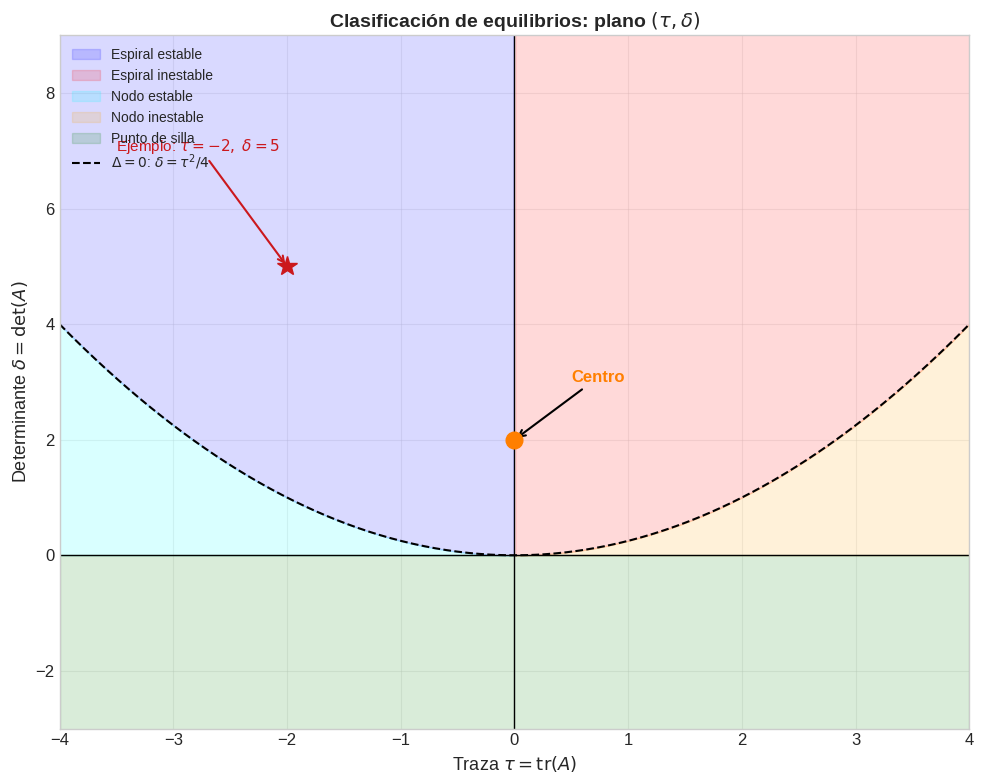

In [8]:
# Diagrama traza-determinante para clasificación de equilibrios
fig, ax = plt.subplots(figsize=(10, 8))

tau = np.linspace(-4, 4, 500)
# Parábola: delta = tau^2/4 (discriminante = 0)
delta_parabola = tau**2 / 4

ax.fill_between(tau, delta_parabola, 10, where=(tau < 0), alpha=0.15, color='blue', label='Espiral estable')
ax.fill_between(tau, delta_parabola, 10, where=(tau > 0), alpha=0.15, color='red', label='Espiral inestable')
ax.fill_between(tau, 0, delta_parabola, where=(tau < 0), alpha=0.15, color='cyan', label='Nodo estable')
ax.fill_between(tau, 0, delta_parabola, where=(tau > 0), alpha=0.15, color='orange', label='Nodo inestable')
ax.fill_between(tau, -5, 0, alpha=0.15, color='green', label='Punto de silla')

ax.plot(tau, delta_parabola, 'k--', lw=1.5, label=r'$\Delta=0$: $\delta=\tau^2/4$')
ax.axhline(y=0, color='black', lw=1)
ax.axvline(x=0, color='black', lw=1)

# Centro
ax.plot(0, 2, 'o', color=COLOR_AUX, ms=12, zorder=5)
ax.annotate('Centro', xy=(0, 2), xytext=(0.5, 3), fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.5), color=COLOR_AUX)

# Ejemplo de la sección 9.9
ax.plot(-2, 5, '*', color=COLOR_RECTA, ms=15, zorder=5)
ax.annotate(r'Ejemplo: $\tau=-2,\;\delta=5$', xy=(-2, 5), xytext=(-3.5, 7), fontsize=11,
            arrowprops=dict(arrowstyle='->', lw=1.5, color=COLOR_RECTA), color=COLOR_RECTA)

ax.set_xlabel(r'Traza $\tau = \text{tr}(A)$', fontsize=13)
ax.set_ylabel(r'Determinante $\delta = \det(A)$', fontsize=13)
ax.set_title(r'Clasificación de equilibrios: plano $(\tau, \delta)$', fontsize=14, fontweight='bold')
ax.set_xlim(-4, 4)
ax.set_ylim(-3, 9)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.10 Tipo 10: Reducción de EDO de orden $n$ a sistema

**Procedimiento detallado paso a paso:**

**Paso 1: Partir de la EDO de orden $n$:**

$$x^{(n)} + a_{n-1}x^{(n-1)} + \cdots + a_1 x' + a_0 x = g(t)$$

**Paso 2: Definir las nuevas variables** (una por cada derivada hasta orden $n-1$):

$$y_1 = x, \quad y_2 = x', \quad y_3 = x'', \quad \ldots, \quad y_n = x^{(n-1)}$$

**Paso 3: Escribir las ecuaciones del sistema.** Las primeras $n-1$ ecuaciones son triviales:

$$y_1' = y_2, \quad y_2' = y_3, \quad \ldots, \quad y_{n-1}' = y_n$$

La última ecuación viene de despejar $x^{(n)}$ de la EDO original:

$$y_n' = x^{(n)} = -a_0 y_1 - a_1 y_2 - \cdots - a_{n-1}y_n + g(t)$$

**Paso 4: Identificar la matriz compañera $A$ y el vector de forzamiento:**

$$A = \begin{pmatrix} 0 & 1 & 0 & \cdots & 0 \\ 0 & 0 & 1 & \cdots & 0 \\ \vdots & & & \ddots & \vdots \\ 0 & 0 & 0 & \cdots & 1 \\ -a_0 & -a_1 & -a_2 & \cdots & -a_{n-1} \end{pmatrix}, \qquad \mathbf{f}(t) = \begin{pmatrix} 0 \\ 0 \\ \vdots \\ 0 \\ g(t) \end{pmatrix}$$

**Propiedad clave:** Los autovalores de $A$ son exactamente las raíces del polinomio característico de la EDO:

$$\lambda^n + a_{n-1}\lambda^{n-1} + \cdots + a_1\lambda + a_0 = 0$$

---

#### Ejercicio resuelto: reducir $x''' + 6x'' + 11x' + 6x = \sin t$

**Paso 1:** Identificamos $n = 3$, $a_0 = 6$, $a_1 = 11$, $a_2 = 6$, $g(t) = \sin t$.

**Paso 2:** Definimos las variables:

$$y_1 = x, \quad y_2 = x', \quad y_3 = x''$$

**Paso 3:** Escribimos el sistema:

$$\begin{cases} y_1' = y_2 \\ y_2' = y_3 \\ y_3' = -6y_1 - 11y_2 - 6y_3 + \sin t \end{cases}$$

La última ecuación viene de: $x''' = -6x - 11x' - 6x'' + \sin t = -6y_1 - 11y_2 - 6y_3 + \sin t$.

**Paso 4:** La forma matricial es $\mathbf{y}' = A\mathbf{y} + \mathbf{f}(t)$:

$$A = \begin{pmatrix} 0 & 1 & 0 \\ 0 & 0 & 1 \\ -6 & -11 & -6 \end{pmatrix}, \qquad \mathbf{f}(t) = \begin{pmatrix} 0 \\ 0 \\ \sin t \end{pmatrix}$$

**Paso 5:** Verificamos los autovalores. El polinomio característico de la EDO es:

$$\lambda^3 + 6\lambda^2 + 11\lambda + 6 = 0$$

Probamos $\lambda = -1$: $(-1)^3 + 6(-1)^2 + 11(-1) + 6 = -1 + 6 - 11 + 6 = 0$ ✓

Dividimos por $(\lambda + 1)$ usando Ruffini:

| | 1 | 6 | 11 | 6 |
|---|---|---|---|---|
| $-1$ | | $-1$ | $-5$ | $-6$ |
| | 1 | 5 | 6 | 0 |

Resultado: $\lambda^2 + 5\lambda + 6 = (\lambda+2)(\lambda+3) = 0$.

$$\boxed{\lambda_1 = -1, \quad \lambda_2 = -2, \quad \lambda_3 = -3}$$

Todos negativos: el sistema homogéneo es **asintóticamente estable**. La solución particular (forzada por $\sin t$) será una oscilación sostenida.

---

**Condiciones iniciales:** Si la EDO original tiene $x(0) = x_0$, $x'(0) = v_0$, $x''(0) = a_0$, entonces para el sistema:

$$\mathbf{y}(0) = \begin{pmatrix} x_0 \\ v_0 \\ a_0 \end{pmatrix}$$

**Error frecuente:** Poner los coeficientes $a_i$ con el signo incorrecto en la última fila de $A$. Recordar que van con signo **negativo** ($-a_0, -a_1, \ldots$).

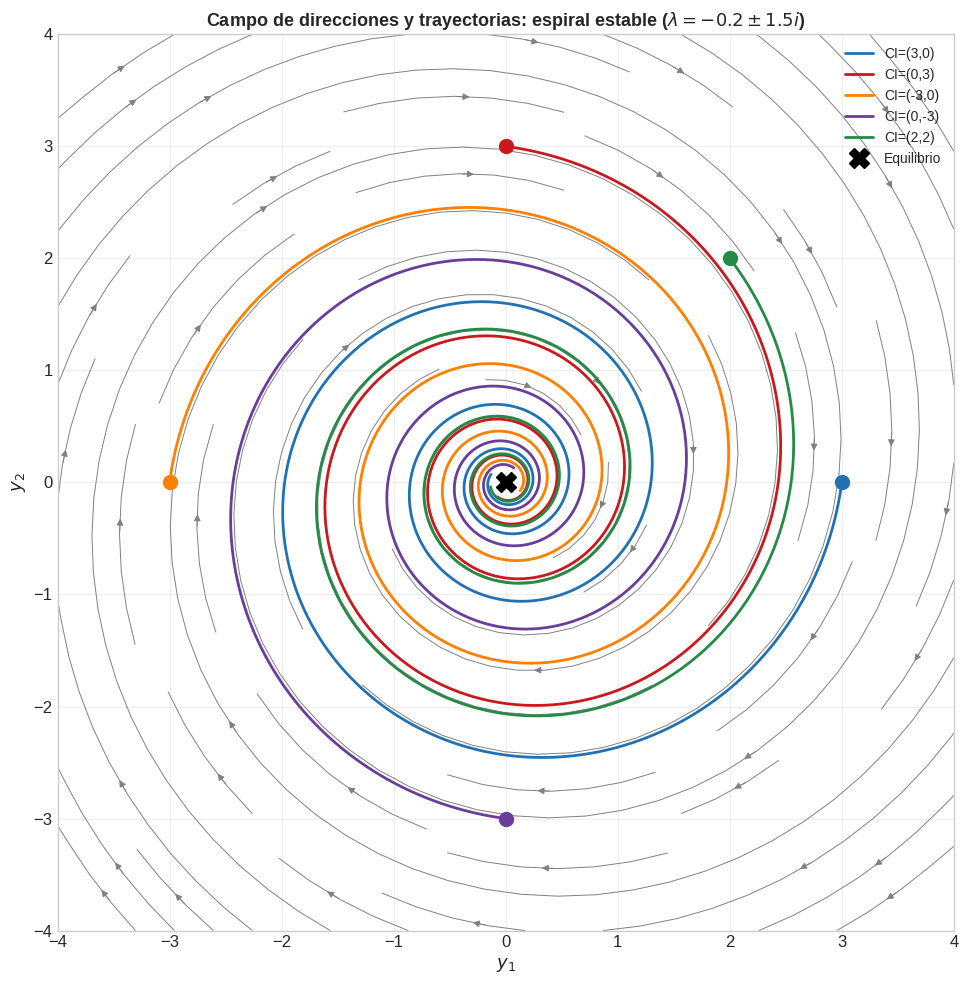

In [9]:
# Campo de direcciones y trayectorias para un sistema 2D genérico
fig, ax = plt.subplots(figsize=(10, 10))

# Sistema: espiral estable con lambda = -0.2 +/- 1.5i
A_demo = np.array([[-0.2, 1.5], [-1.5, -0.2]])
Y_g, X_g = np.mgrid[-4:4:20j, -4:4:20j]
U_g = A_demo[0, 0] * X_g + A_demo[0, 1] * Y_g
V_g = A_demo[1, 0] * X_g + A_demo[1, 1] * Y_g

ax.streamplot(X_g, Y_g, U_g, V_g, color='gray', density=0.8, linewidth=0.7)

# Varias trayectorias con distintas CI
colores = [COLOR_PRINCIPAL, COLOR_RECTA, COLOR_AUX, COLOR_AUX2, COLOR_PUNTO]
cis = [[3, 0], [0, 3], [-3, 0], [0, -3], [2, 2]]
for ci, col in zip(cis, colores):
    sol = solve_ivp(lambda t, y: A_demo @ y, [0, 15], ci, t_eval=np.linspace(0, 15, 1000))
    ax.plot(sol.y[0], sol.y[1], color=col, lw=2, label=f'CI=({ci[0]},{ci[1]})')
    ax.plot(ci[0], ci[1], 'o', color=col, ms=10, zorder=5)

ax.plot(0, 0, 'X', color='black', ms=15, zorder=6, label='Equilibrio')
ax.set_xlabel(r'$y_1$')
ax.set_ylabel(r'$y_2$')
ax.set_title(r'Campo de direcciones y trayectorias: espiral estable ($\lambda=-0.2\pm 1.5i$)',
             fontsize=13, fontweight='bold')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 10. Resumen y tabla de fórmulas clave

| Fórmula | Uso |
|---------|-----|
| $\boxed{\mathbf{y}=c_1 e^{\lambda_1 t}\mathbf{u}_1+c_2 e^{\lambda_2 t}\mathbf{u}_2}$ | Homogéneo con autovalores reales distintos |
| $\boxed{e^{\alpha t}[\mathbf{v}\cos\beta t-\mathbf{w}\sin\beta t]}$ | Solución real a partir de autovalor complejo $\alpha+i\beta$ |
| $\boxed{\mathbf{y}_2=e^{\lambda t}(t\mathbf{u}+\mathbf{w})}$ | Autovalor repetido no diagonalizable (2a solución) |
| $\boxed{\mathbf{y}_p=Y(t)\int Y^{-1}\mathbf{f}\,dt}$ | Variación de parámetros |
| $\boxed{(\mu I-A)\mathbf{c}=\mathbf{b}}$ | Coeficientes indeterminados ($\mu$ no autovalor) |
| $\boxed{\mathbf{Y}(s)=(sI-A)^{-1}[\mathbf{y}_0+\mathbf{F}(s)]}$ | Método de Laplace |
| $\det(A)<0 \implies$ silla | Clasificación rápida |
| $\text{tr}(A)<0,\;\det(A)>0 \implies$ estable | Clasificación rápida |
| $\Delta=\tau^2-4\delta<0 \implies$ espiral/centro | Discriminante del plano $(\tau,\delta)$ |
| $W(t)=W(t_0)e^{\text{tr}(A)(t-t_0)}$ | Fórmula de Abel-Liouville |

**Regla mnemotécnica para la estabilidad:** "Traza negativa = amortiguamiento = estable".